# This notebook fit a GEV to maximum annual percipitation using MLE and bayesian methods
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [ ]:
#import libraries
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
import pandas as pd
import numpy as np
import pymc3 as pm3
import scipy.stats as stats
from scipy import stats
from scipy.stats import genextreme
from scipy.stats import norm, gaussian_kde
from scipy.optimize import minimize
import seaborn as sns
import arviz as az
import pymc3 as pm
import os
import theano.tensor as tt
from theano.compile.ops import as_op
import theano
from pymc3.distributions.dist_math import bound
from scipy.stats import genextreme
import warnings
from arviz.plots import plot_utils as azpu
import arviz as az
from tqdm import tqdm
%matplotlib inline
sns.set()
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', UserWarning)
theano.config.warn.round=False
from watermark import watermark
from datetime import datetime
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from matplotlib.legend_handler import HandlerPathCollection
from matplotlib.collections import PathCollection
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re


# Read the data

In [2]:
# --- Paths ---
BASE_DIR = r"D:\BMM-IDF4Drainage_data_results\Data\AORC"
CITIES_CSV = r"D:\BMM-IDF4Drainage_data_results\us_cities_coordinates.csv"

# --- Load city list ---
cities_df = pd.read_csv(CITIES_CSV)
city_names = cities_df["City"].astype(str).str.strip().tolist()

# --- Final container ---
dataframes = {}

# --- Helper to read a CSV safely ---
def read_if_exists(path, usecols=None):
    if os.path.exists(path):
        return pd.read_csv(path, usecols=usecols)
    return None

# --- Build combined structure ---
for city_full in city_names:
    # Strip the state to get short name
    city_short = city_full.split(",")[0].strip()

    # Paths to the hourly and daily data
    hourly_path = os.path.join(BASE_DIR, city_full, f"{city_full}_annual_max_hourly.csv")
    daily_path  = os.path.join(BASE_DIR, city_full, f"{city_full}_annual_max_daily.csv")

    df_hourly = read_if_exists(hourly_path, usecols=["year", "max_hourly_mm"])
    df_daily  = read_if_exists(daily_path,  usecols=["year", "max_daily_mm"])

    if df_hourly is not None and df_daily is not None:
        # Keep only the common years between both
        df = pd.merge(df_hourly, df_daily, on="year", how="inner")

        # Rename columns to match your original structure
        df.rename(columns={"max_hourly_mm": "1h", "max_daily_mm": "24h"}, inplace=True)

        # Filter to 1979–2024 (if desired)
        df = df[df["year"].between(1979, 2024)]

        # Sort by year and reset index
        df = df.sort_values("year").reset_index(drop=True)

        # Save to dict with short name
        dataframes[city_short] = df

# --- print ---
print(dataframes["Birmingham"].head())
print(dataframes["Phoenix"])
print(list(dataframes.keys()))
# cities names
cities = ['Birmingham', 'Phoenix', 'Little Rock', 'Los Angeles', 'Denver', 'Hartford', 'Wilmington', 'Miami', 'Atlanta', 'Boise',
           'Chicago', 'Indianapolis', 'Des Moines', 'Wichita', 'Louisville', 'New Orleans', 'Portland', 'Baltimore', 'Boston', 'Detroit',
             'Minneapolis', 'Jackson', 'St. Louis', 'Billings', 'Omaha', 'Las Vegas', 'Manchester', 'Newark', 'Albuquerque', 'New York City',
               'Charlotte', 'Fargo', 'Columbus', 'Oklahoma City', 'Philadelphia', 'Providence', 'Charleston', 'Sioux Falls', 'Nashville', 'Houston',
                 'Salt Lake City', 'Burlington', 'Richmond', 'Seattle', 'Milwaukee', 'Cheyenne']             



   year         1h         24h
0  1979  21.200000  135.500002
1  1980  18.300000  102.500002
2  1981  43.200001   77.800001
3  1982  35.500001   74.100001
4  1983  24.100000  103.300002
    year         1h        24h
0   1979   8.400000  31.300000
1   1980   3.500000  14.100000
2   1981   4.600000  22.600000
3   1982   6.800000  24.700000
4   1983   9.700000  40.700001
5   1984   8.400000  32.300000
6   1985  10.400000  27.200000
7   1986   5.700000  28.900000
8   1987  15.000000  34.300001
9   1988   4.700000  26.100000
10  1989  20.400000  29.400000
11  1990   7.900000  29.400000
12  1991  20.200000  25.200000
13  1992  13.500000  42.400001
14  1993   7.700000  35.000001
15  1994  10.800000  15.300000
16  1995   6.800000  21.200000
17  1996   5.900000  11.300000
18  1997  11.300000  17.600000
19  1998   9.500000  18.200000
20  1999  11.900000  26.600000
21  2000   8.300000  51.100001
22  2001   6.000000  16.800000
23  2002   7.200000  13.700000
24  2003  16.100000  32.700000
25  2004

# Method biases 

## NYC

### Stationary


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     203
L-moments    182
MLE          115
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     203
L-moments    182
MLE          115
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


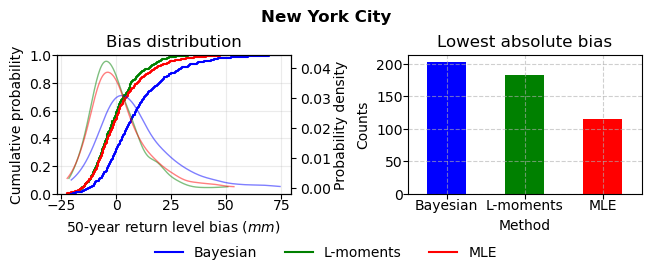

In [153]:
plt.style.use('default')
# --- file paths for stationary NYC ---
p_bayes = r"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\bias_sim_series_New York City.csv"
p_lmom  = r"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Stationary\bias_sim_series_1hr_Lmoments_New York City_N46.csv"
p_mle   = r"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Stationary\bias_sim_series_1hr_MLE_New York City_N46.csv"

# --- requested colors ---
MLE_COLOR      = "red"
MOM_COLOR      = "green"
Beysian_color  = "blue"     # (spelling kept as requested)

METHOD_COLORS = {
    "Bayesian": Beysian_color,
    "L-moments": MOM_COLOR,
    "MLE": MLE_COLOR,
}

def prep_df(path, label):
    df = pd.read_csv(path)
    # find 'bias_t50' column (case-insensitive)
    col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
    out = df[["sim"]].copy()
    out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
    out["Method"] = label
    return out

bayes = prep_df(p_bayes, "Bayesian")
lmom  = prep_df(p_lmom,  "L-moments")
mle   = prep_df(p_mle,   "MLE")
all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

# sort sims numerically if they look like "..._12"
def sim_key(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else x

all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

# -------------------------
# Compute per-simulation alpha based on absolute bias:
# lowest abs(bias) -> high alpha; highest -> low alpha; middle -> mid alpha.
# Ties: all minima get high alpha; all maxima get low alpha; otherwise mid.
# -------------------------
pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
abs_bias = pivot.abs()

min_per_sim = abs_bias.min(axis=1)
max_per_sim = abs_bias.max(axis=1)

# map back to long form
def alpha_for_row(row):
    # row: a Series with columns ['sim','Method','bias_t50']
    sim = row['sim']
    val = abs(row['bias_t50'])
    if np.isfinite(val):
        if np.isclose(val, min_per_sim.loc[sim], rtol=0, atol=1e-12):
            return 1.0   # highest opacity for winners
        elif np.isclose(val, max_per_sim.loc[sim], rtol=0, atol=1e-12):
            return 0.2   # faintest for worst
        else:
            return 0.6   # middle
    return 0.2

all_df['alpha'] = all_df.apply(alpha_for_row, axis=1)

# -------------------------
# Prepare winners/ECDF counts (same logic as your original)
# -------------------------
row_mins = abs_bias.min(axis=1)
winners_mask = abs_bias.eq(row_mins, axis=0)
winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

is_single = ~winner_label.str.contains("&")
counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

tie_only = winner_label[~is_single]
tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

print("\n=== Lowest absolute bias_t50 (including ties) ===")
print(counts_incl_ties)
print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
print(counts_excl_ties)
print("\n=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===")
print(tie_sizes)

# -------------------------
# PLOTTING: three plots in one row
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)


# 1) ECDF of bias_t50 (seaborn), with your colors
ax = axes[0]
sns.ecdfplot(
    data=all_df,
    x="bias_t50",
    hue="Method",
    palette=METHOD_COLORS,
    ax=ax
)

ax.set_xlabel(f"50-year return level bias ($mm$)")
ax.set_ylabel("Cumulative probability")
ax.set_title("Bias distribution")
ax.grid(True, linestyle="-", alpha=0.25)

# tighter spacing
ax.tick_params(axis="both", which="major", pad=0)

# move legend away (this panel has its own legend or none)
ax.legend_.remove()

# ----------------------------------------------------
# Add PDF (kernel density) on a twin axis
# ----------------------------------------------------
ax_pdf = ax.twinx()
ax_pdf.set_ylabel("Probability density", labelpad=2)

for name, g in all_df.groupby("Method"):
    color = METHOD_COLORS[name]
    x = g["bias_t50"].to_numpy()

    # KDE (requires scipy)
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 300)
    pdf = kde(xs)

    ax_pdf.plot(xs, pdf, color=color, linewidth=1, alpha=0.5)



# 2) Bar chart of winners (excluding ties)
ax = axes[1]
# Ensure consistent color order with methods present in counts
bar_colors = [METHOD_COLORS.get(m, "0.5") for m in counts_excl_ties.index]
counts_excl_ties.plot(kind="bar", ax=ax, color=bar_colors)
ax.set_ylabel("Counts")
ax.set_title("Lowest absolute bias")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("Method")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis="both", which="major", pad=0)

# ---- Combined line + point legend (Option B) ----
handles = []
labels = []
for name, color in METHOD_COLORS.items():

    # one line handle
    line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)


    # combine them into a single legend entry
    combo = ( line_h)

    handles.append(combo)
    labels.append(name)

fig.legend(handles, labels,
           handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)},
           loc='lower center',
           ncol=3,
           frameon=False,
           bbox_to_anchor=(0.5, -0.15))
fig.suptitle("New York City", 
             fontsize=12,
             fontweight="bold", 
             y=1.1)
plt.show()

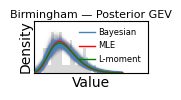

Saved left panel to: D:\BMM-IDF4Drainage_data_results\Figure\Birmingham_PosteriorGEV_LeftPanel.png


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import genextreme

# ==========================================================
# INPUTS
# ==========================================================
city_name = "Birmingham"   # <--- CHANGE HERE IF NEEDED

# Files
p_mle  = r"D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_1h_mle_AORC.csv"
p_mom  = r"D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv"
p_post = r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz"

# Observed data dictionary must already exist:
# data1 = np.array(dataframes.get(city_name)["1h"])

# City index (find row in your cities list)
i = cities.index(city_name)

# ==========================================================
# LOAD ALL DATA
# ==========================================================
mle_params = pd.read_csv(p_mle)
mom_params = pd.read_csv(p_mom)
post = np.load(p_post)["saved_samples_1h_AORC"]

# posterior samples
xi_s    = post[i, 0, :]
mu_s    = post[i, 1, :]
sigma_s = post[i, 2, :]

# subset posterior
K = min(2000, xi_s.size)
rng = np.random.default_rng(12345)
idx = rng.choice(xi_s.size, size=K, replace=False)

xi_sub    = xi_s[idx]
mu_sub    = mu_s[idx]
sigma_sub = sigma_s[idx]

# predictive range
x_pred = genextreme.rvs(c=-xi_sub, loc=mu_sub, scale=sigma_sub, random_state=rng)
x_lo, x_hi = np.nanpercentile(x_pred, [0.005, 99.5])
x = np.linspace(x_lo, x_hi, 500)

# posterior PDF stack
pdf_stack = np.empty((K, x.size))
for j in range(K):
    pdf_stack[j, :] = genextreme.pdf(x, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

# observed data (1h maxima)
data1 = np.array(dataframes.get(city_name)["1h"])

# ==========================================================
# MLE PARAMETERS
# ==========================================================
row_mle = mle_params.loc[mle_params["City"] == city_name].iloc[0]
c_mle     = float(row_mle["shape(c)"])
loc_mle   = float(row_mle["loc"])
scale_mle = float(row_mle["scale"])

pdf_mle = genextreme.pdf(x, c=c_mle, loc=loc_mle, scale=scale_mle)

# ==========================================================
# L-MOMENT PARAMETERS
# ==========================================================
row_mom = mom_params.loc[mom_params["City"] == city_name].iloc[0]
c_mom     = float(row_mom["shape(c)"])
loc_mom   = float(row_mom["loc"])
scale_mom = float(row_mom["scale"])

pdf_mom = genextreme.pdf(x, c=c_mom, loc=loc_mom, scale=scale_mom)

# ==========================================================
# PLOT — MINIMALIST LEFT PANEL
# ==========================================================
fig, ax = plt.subplots(figsize=(1.6, 1.1))   # small: same style as earlier

# histogram
ax.hist(data1, bins=20, density=True,
        color="black", alpha=0.15, linewidth=0)

# posterior GEV curves
for j in range(K):
    ax.plot(
        x, pdf_stack[j, :],
        color="steelblue",
        alpha=0.03,
        linewidth=0.1,
        zorder=1
    )

# MLE curve
ax.plot(x, pdf_mle, lw=1.0, color="red", alpha=0.8, label="MLE", zorder=4)

# L-moment curve
ax.plot(x, pdf_mom, lw=1.0, color="green", alpha=0.8, label="L-moment", zorder=5)

# formatting
ax.set_xlabel("Value", labelpad=2)
ax.set_ylabel("Density", labelpad=1)
ax.set_xlim(1, 100)
ax.set_ylim(bottom=0)

ax.set_xticks([])
ax.set_yticks([])

ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

# Legend including Bayesian
legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=1.0, label="Bayesian"),
    Line2D([0], [0], color="red",       linewidth=1.0, label="MLE"),
    Line2D([0], [0], color="green",     linewidth=1.0, label="L-moment")
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=6,
    handlelength=2.0,
    handletextpad=0.3
)

ax.set_title(f"{city_name} — Posterior GEV", fontsize=8, pad=2)

plt.tight_layout()
plt.show()

# SAVE
outpath = fr"D:\BMM-IDF4Drainage_data_results\Figure\{city_name}_PosteriorGEV_LeftPanel.png"
fig.savefig(outpath, dpi=300, bbox_inches="tight")
plt.close(fig)

print("Saved left panel to:", outpath)


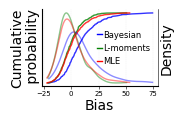

In [198]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
from matplotlib.lines import Line2D

fig, ax_cdf = plt.subplots(figsize=(1.5, 1))

# ------------------------------------------------------
# AXIS STYLING
# ------------------------------------------------------
ax_cdf.spines['top'].set_visible(False)
ax_cdf.spines['right'].set_visible(False)
ax_cdf.spines['left'].set_linewidth(0.4)
ax_cdf.spines['bottom'].set_linewidth(0.4)

ax_cdf.tick_params(axis='both', length=2, width=0.4, labelsize=5, pad=1)
ax_cdf.grid(True, linestyle="--", linewidth=0.25, alpha=0.25)

# Twin axis for PDF
ax_pdf = ax_cdf.twinx()
ax_pdf.spines['top'].set_visible(False)
ax_pdf.spines['right'].set_linewidth(0.4)
ax_pdf.tick_params(axis='y', length=2, width=0.4, labelsize=5, pad=1)

# ------------------------------------------------------
# PLOTTING ECDF + PDF
# ------------------------------------------------------
for method, color in METHOD_COLORS.items():

    sub = all_df[all_df["Method"] == method]
    x = sub["bias_t50"].dropna().values
    if len(x) < 3:
        continue

    # --- ECDF ---
    xs = np.sort(x)
    ys = np.linspace(0, 1, len(xs))
    ax_cdf.plot(xs, ys, color=color, linewidth=1, alpha=0.8)

    # --- PDF ---
    kde = gaussian_kde(x)
    grid = np.linspace(xs.min(), xs.max(), 300)
    pdf = kde(grid)
    ax_pdf.plot(grid, pdf, color=color, linewidth=1, alpha=0.45)

# ------------------------------------------------------
# LABELS
# ------------------------------------------------------
ax_cdf.set_xlabel("Bias", fontsize=10, labelpad=1)
ax_cdf.set_ylabel("Cumulative\n probability", fontsize=10, labelpad=1)
ax_pdf.set_ylabel("Density", fontsize=10, labelpad=1)
ax_cdf.set_yticks([])
ax_pdf.set_yticks([])


# ------------------------------------------------------
# LEGEND (blue = Bayesian, green = L-moments, red = MLE)
# ------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color="blue",  lw=1, label="Bayesian"),
    Line2D([0], [0], color="green", lw=1, label="L-moments"),
    Line2D([0], [0], color="red",   lw=1, label="MLE"),
]

ax_cdf.legend(
    handles=legend_handles,
    loc="center right",
    fontsize=6,
    frameon=False,
    handlelength=0.5,
    handletextpad=0.2,
    columnspacing=0.4,            # tighter spacing between columns
    ncol=1
)

plt.tight_layout(pad=200)
plt.show()

fig.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Figure\NYC_bias_leftpanel_CDF_PDF_twinaxis_with_legend_micro.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


### Noisy stationary


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     208
L-moments    181
MLE          111
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     208
L-moments    181
MLE          111
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


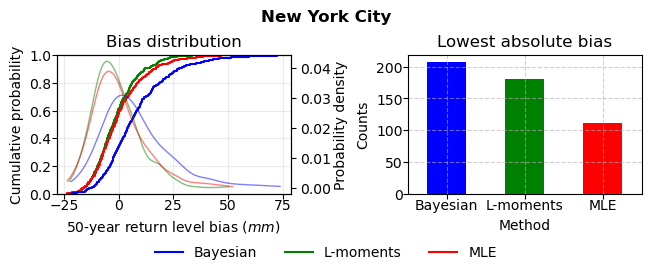

In [224]:
# --- file paths for stationary NYC ---
p_bayes = r"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\bias_sim_series_New York City_noisy.csv"
p_lmom  = r"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Noise_stationary\bias_sim_series_1hr_Lmoments_New York City_N46.csv"
p_mle   = r"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Noise_stationary\bias_sim_series_1hr_MLE_New York City_N46.csv"
# --- requested colors ---
MLE_COLOR      = "red"
MOM_COLOR      = "green"
Beysian_color  = "blue"     # (spelling kept as requested)

METHOD_COLORS = {
    "Bayesian": Beysian_color,
    "L-moments": MOM_COLOR,
    "MLE": MLE_COLOR,
}

def prep_df(path, label):
    df = pd.read_csv(path)
    # find 'bias_t50' column (case-insensitive)
    col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
    out = df[["sim"]].copy()
    out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
    out["Method"] = label
    return out

bayes = prep_df(p_bayes, "Bayesian")
lmom  = prep_df(p_lmom,  "L-moments")
mle   = prep_df(p_mle,   "MLE")
all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

# sort sims numerically if they look like "..._12"
def sim_key(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else x

all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

# -------------------------
# Compute per-simulation alpha based on absolute bias:
# lowest abs(bias) -> high alpha; highest -> low alpha; middle -> mid alpha.
# Ties: all minima get high alpha; all maxima get low alpha; otherwise mid.
# -------------------------
pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
abs_bias = pivot.abs()

min_per_sim = abs_bias.min(axis=1)
max_per_sim = abs_bias.max(axis=1)

# map back to long form
def alpha_for_row(row):
    # row: a Series with columns ['sim','Method','bias_t50']
    sim = row['sim']
    val = abs(row['bias_t50'])
    if np.isfinite(val):
        if np.isclose(val, min_per_sim.loc[sim], rtol=0, atol=1e-12):
            return 1   # highest opacity for winners
        elif np.isclose(val, max_per_sim.loc[sim], rtol=0, atol=1e-12):
            return 0.5   # faintest for worst
        else:
            return 0.75   # middle
    return 0.5

all_df['alpha'] = all_df.apply(alpha_for_row, axis=1)

# -------------------------
# Prepare winners/ECDF counts (same logic as your original)
# -------------------------
row_mins = abs_bias.min(axis=1)
winners_mask = abs_bias.eq(row_mins, axis=0)
winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

is_single = ~winner_label.str.contains("&")
counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

tie_only = winner_label[~is_single]
tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

print("\n=== Lowest absolute bias_t50 (including ties) ===")
print(counts_incl_ties)
print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
print(counts_excl_ties)
print("\n=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===")
print(tie_sizes)

# -------------------------
# PLOTTING: three plots in one row
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)


# 1) ECDF of bias_t50 (seaborn), with your colors
ax = axes[0]
sns.ecdfplot(
    data=all_df,
    x="bias_t50",
    hue="Method",
    palette=METHOD_COLORS,
    ax=ax
)

ax.set_xlabel(f"50-year return level bias ($mm$)")
ax.set_ylabel("Cumulative probability")
ax.set_title("Bias distribution")
ax.grid(True, linestyle="-", alpha=0.25)

# tighter spacing
ax.tick_params(axis="both", which="major", pad=0)

# move legend away (this panel has its own legend or none)
ax.legend_.remove()

# ----------------------------------------------------
# Add PDF (kernel density) on a twin axis
# ----------------------------------------------------
ax_pdf = ax.twinx()
ax_pdf.set_ylabel("Probability density", labelpad=2)

for name, g in all_df.groupby("Method"):
    color = METHOD_COLORS[name]
    x = g["bias_t50"].to_numpy()

    # KDE (requires scipy)
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 300)
    pdf = kde(xs)

    ax_pdf.plot(xs, pdf, color=color, linewidth=1, alpha=0.5)



# 2) Bar chart of winners (excluding ties)
ax = axes[1]
# Ensure consistent color order with methods present in counts
bar_colors = [METHOD_COLORS.get(m, "0.5") for m in counts_excl_ties.index]
counts_excl_ties.plot(kind="bar", ax=ax, color=bar_colors)
ax.set_ylabel("Counts")
ax.set_title("Lowest absolute bias")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("Method")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis="both", which="major", pad=0)

# ---- Combined line + point legend (Option B) ----
handles = []
labels = []
for name, color in METHOD_COLORS.items():

    # one line handle
    line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)


    # combine them into a single legend entry
    combo = ( line_h)

    handles.append(combo)
    labels.append(name)

fig.legend(handles, labels,
           handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)},
           loc='lower center',
           ncol=3,
           frameon=False,
           bbox_to_anchor=(0.5, -0.15))
fig.suptitle("New York City", 
             fontsize=12,
             fontweight="bold", 
             y=1.1)
plt.show()

### Noisy nonstationary

In [ ]:
# --- file paths for stationary NYC ---
p_bayes = r"d:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\_nonstationary_bias_sim_series_New York City.csv"
p_lmom  = r"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Nonstationary\bias_sim_series_1hr_MLE_New York City_N46.csv"
p_mle   = r"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Nonstationary\bias_sim_series_1hr_MLE_New York City_N46.csv"
# --- requested colors ---
MLE_COLOR      = "red"
MOM_COLOR      = "green"
Beysian_color  = "blue"  

METHOD_COLORS = {
    "Bayesian": Beysian_color,
    "L-moments": MOM_COLOR,
    "MLE": MLE_COLOR,
}

def prep_df(path, label):
    df = pd.read_csv(path)
    # find 'bias_t50' column (case-insensitive)
    col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
    out = df[["sim"]].copy()
    out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
    out["Method"] = label
    return out

bayes = prep_df(p_bayes, "Bayesian")
lmom  = prep_df(p_lmom,  "L-moments")
mle   = prep_df(p_mle,   "MLE")
all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

# sort sims numerically if they look like "..._12"
def sim_key(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else x

all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

# -------------------------
# Compute per-simulation alpha based on absolute bias:
# lowest abs(bias) -> high alpha; highest -> low alpha; middle -> mid alpha.
# Ties: all minima get high alpha; all maxima get low alpha; otherwise mid.
# -------------------------
pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
abs_bias = pivot.abs()

# -------------------------
# Probability of zero bias (per method for this city)
# -------------------------
zero_prob_city = {}

for method in pivot.columns:
    col = pivot[method].dropna()
    if len(col) == 0:
        p_zero = np.nan
    else:
        p_zero = np.mean(col == 0)
    zero_prob_city[method] = p_zero

# store results
records_zero_prob.append({
    "City": city_n,
    **zero_prob_city
})

# ============================
# Summary across all cities
# ============================
df_zero_prob = pd.DataFrame(records_zero_prob)

print("\n\n==============================================")
print("Probability of zero bias for each city × method")
print("==============================================")
print(df_zero_prob.to_string(index=False))

avg_zero_prob = df_zero_prob.mean(numeric_only=True)

print("\n==============================================")
print("Average zero-bias probability per method")
print("==============================================")
print(avg_zero_prob.to_string())

min_per_sim = abs_bias.min(axis=1)
max_per_sim = abs_bias.max(axis=1)

# map back to long form
def alpha_for_row(row):
    # row: a Series with columns ['sim','Method','bias_t50']
    sim = row['sim']
    val = abs(row['bias_t50'])
    if np.isfinite(val):
        if np.isclose(val, min_per_sim.loc[sim], rtol=0, atol=1e-12):
            return 1.0   # highest opacity for winners
        elif np.isclose(val, max_per_sim.loc[sim], rtol=0, atol=1e-12):
            return 0.2   # faintest for worst
        else:
            return 0.6   # middle
    return 0.2

all_df['alpha'] = all_df.apply(alpha_for_row, axis=1)

# -------------------------
# Prepare winners/ECDF counts (same logic as your original)
# -------------------------
row_mins = abs_bias.min(axis=1)
winners_mask = abs_bias.eq(row_mins, axis=0)
winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

is_single = ~winner_label.str.contains("&")
counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

tie_only = winner_label[~is_single]
tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

print("\n=== Lowest absolute bias_t50 (including ties) ===")
print(counts_incl_ties)
print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
print(counts_excl_ties)
print("\n=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===")
print(tie_sizes)

# -------------------------
# PLOTTING: three plots in one row
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)


# 1) ECDF of bias_t50 (seaborn), with your colors
ax = axes[0]
sns.ecdfplot(
    data=all_df,
    x="bias_t50",
    hue="Method",
    palette=METHOD_COLORS,
    ax=ax
)

ax.set_xlabel(f"50-year return level bias ($mm$)")
ax.set_ylabel("Cumulative probability")
ax.set_title("Bias distribution")
ax.grid(True, linestyle="-", alpha=0.25)

# tighter spacing
ax.tick_params(axis="both", which="major", pad=0)

# move legend away (this panel has its own legend or none)
ax.legend_.remove()

# ----------------------------------------------------
# Add PDF (kernel density) on a twin axis
# ----------------------------------------------------
ax_pdf = ax.twinx()
ax_pdf.set_ylabel("Probability density", labelpad=2)

for name, g in all_df.groupby("Method"):
    color = METHOD_COLORS[name]
    x = g["bias_t50"].to_numpy()

    # KDE (requires scipy)
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 300)
    pdf = kde(xs)

    ax_pdf.plot(xs, pdf, color=color, linewidth=1, alpha=0.5)



# 2) Bar chart of winners (excluding ties)
ax = axes[1]
# Ensure consistent color order with methods present in counts
bar_colors = [METHOD_COLORS.get(m, "0.5") for m in counts_excl_ties.index]
counts_excl_ties.plot(kind="bar", ax=ax, color=bar_colors)
ax.set_ylabel("Counts")
ax.set_title("Lowest absolute bias")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("Method")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis="both", which="major", pad=0)

# ---- Combined line + point legend (Option B) ----
handles = []
labels = []
for name, color in METHOD_COLORS.items():

    # one line handle
    line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)


    # combine them into a single legend entry
    combo = ( line_h)

    handles.append(combo)
    labels.append(name)

fig.legend(handles, labels,
           handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)},
           loc='lower center',
           ncol=3,
           frameon=False,
           bbox_to_anchor=(0.5, -0.15))
fig.suptitle("New York City", 
             fontsize=12,
             fontweight="bold", 
             y=1.1)
plt.show()

## ALL cities

### Stationary

In [5]:
plt.style.use('default')




Processing: Birmingham

=== Lowest absolute bias_t50 (including ties) ===
MLE          184
Bayesian     180
L-moments    126
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
MLE          184
Bayesian     180
L-moments    126
Name: count, dtype: int64

=== Tie size breakdown ===
Series([], Name: count, dtype: int64)


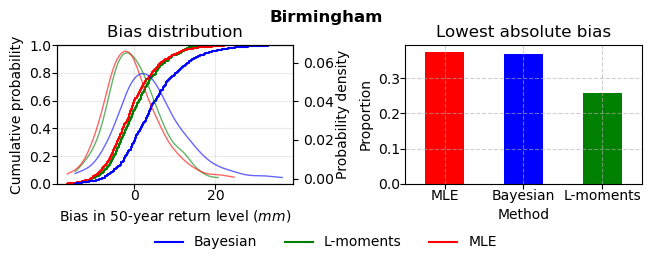



Processing: Little Rock

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     199
L-moments    162
MLE          139
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     199
L-moments    162
MLE          139
Name: count, dtype: int64

=== Tie size breakdown ===
Series([], Name: count, dtype: int64)


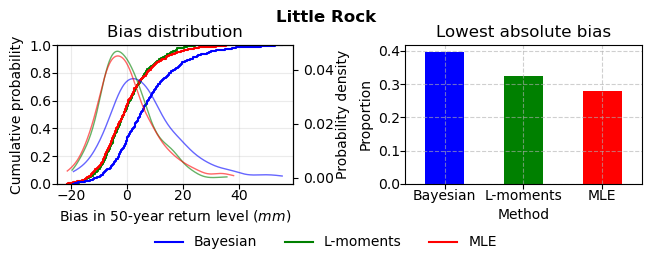



Processing: Phoenix

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     202
L-moments    183
MLE          115
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     202
L-moments    183
MLE          115
Name: count, dtype: int64

=== Tie size breakdown ===
Series([], Name: count, dtype: int64)


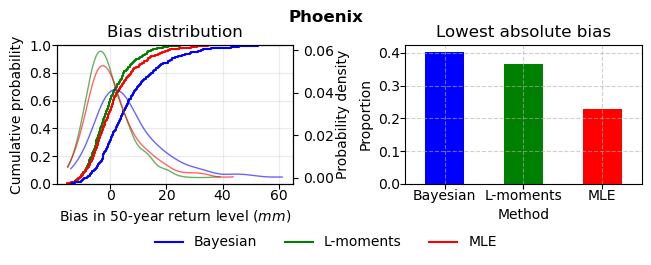



Processing: Los Angeles

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     184
MLE          173
L-moments    130
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     184
MLE          173
L-moments    130
Name: count, dtype: int64

=== Tie size breakdown ===
Series([], Name: count, dtype: int64)


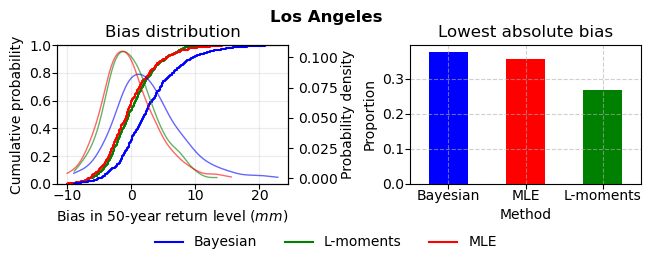



Processing: New York City

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     203
L-moments    182
MLE          115
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     203
L-moments    182
MLE          115
Name: count, dtype: int64

=== Tie size breakdown ===
Series([], Name: count, dtype: int64)


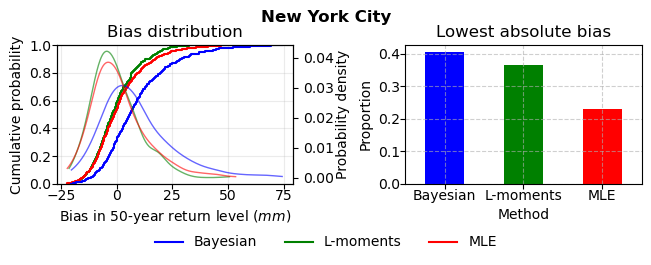



Probability of zero bias for each city × method
         City  Bayesian  L-moments      MLE
   Birmingham  0.306122   0.532653 0.602041
  Little Rock  0.322000   0.546000 0.568000
      Phoenix  0.310000   0.602000 0.530000
  Los Angeles  0.314168   0.533881 0.587269
New York City  0.312000   0.584000 0.534000

Average zero-bias probability per method
Bayesian     0.312858
L-moments    0.559707
MLE          0.564262


In [288]:
city_names = ["Birmingham", "Little Rock", "Phoenix", "Los Angeles", "New York City"]

# ================================
# Storage for zero-bias probabilities
# ================================
records_zero_prob = []

for city_n in city_names:

    print("\n\n============================")
    print("Processing:", city_n)
    print("============================")

    # --- file paths ---
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Stationary\bias_sim_series_{city_n}_N46.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Stationary\bias_sim_series_1hr_Lmoments_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Stationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"

    # --- colors ---
    METHOD_COLORS = {
        "Bayesian": "blue",
        "L-moments": "green",
        "MLE": "red",
    }

    def prep_df(path, label):
        df = pd.read_csv(path)
        col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")

    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

    # remove sims where Bayesian = 0
    bayes_zero_sims = bayes.loc[bayes["bias_t50"] == 0, "sim"]
    all_df = all_df[~all_df["sim"].isin(bayes_zero_sims)]

    # remove incomplete simulations
    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    # rebuild pivot
    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # sorting by sim number
    def sim_key(x):
        m = re.search(r"(\d+)", str(x))
        return int(m.group(1)) if m else x

    all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

    # -------------------------
    # Zero-bias probability using ECDF evaluated at 0
    # -------------------------
    zero_prob_city = {}

    for method in pivot.columns:
        col = pivot[method].dropna().to_numpy()
        if len(col) == 0:
            p_zero = np.nan
        else:
            # ECDF(0) = proportion of values ≤ 0
            p_zero = np.mean(col <= 0)
        zero_prob_city[method] = p_zero

    records_zero_prob.append({
        "City": city_n,
        **zero_prob_city
    })

    # -------------------------
    # Alpha based on bias ranking
    # -------------------------
    min_per_sim = abs_bias.min(axis=1)
    max_per_sim = abs_bias.max(axis=1)

    def alpha_for_row(row):
        sim = row["sim"]
        val = abs(row["bias_t50"])
        if np.isfinite(val):
            if np.isclose(val, min_per_sim.loc[sim]):
                return 1.0
            elif np.isclose(val, max_per_sim.loc[sim]):
                return 0.2
            else:
                return 0.6
        return 0.2

    all_df["alpha"] = all_df.apply(alpha_for_row, axis=1)

    # -------------------------
    # Winner counts
    # -------------------------
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    tie_only = winner_label[~is_single]
    tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

    # -------------------------
    # PRINT RESULTS
    # -------------------------
    print("\n=== Lowest absolute bias_t50 (including ties) ===")
    print(counts_incl_ties)

    print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
    print(counts_excl_ties)

    print("\n=== Tie size breakdown ===")
    print(tie_sizes)

    # -------------------------
    # FIGURE — 2 panels
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)

    # Panel 1 — ECDF + PDF
    ax = axes[0]
    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )
    ax.set_xlabel(f"Bias in 50-year return level ($mm$)")
    ax.set_ylabel("Cumulative probability")
    ax.set_title("Bias distribution")
    ax.grid(True, linestyle="-", alpha=0.25)
    ax.tick_params(axis="both", which="major", pad=0)
    ax.legend_.remove()

    # PDF twin axis
    ax_pdf = ax.twinx()
    ax_pdf.set_ylabel("Probability density", labelpad=2)

    for name, g in all_df.groupby("Method"):
        g = g.dropna(subset=["bias_t50"])
        if len(g) < 2:
            continue

        x = g["bias_t50"].to_numpy()
        kde = gaussian_kde(x)
        xs = np.linspace(x.min(), x.max(), 300)
        pdf = kde(xs)
        ax_pdf.plot(xs, pdf, color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    # Panel 2 — winner proportions
    ax = axes[1]
    proportions = counts_excl_ties / counts_excl_ties.sum()
    bar_colors = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]
    proportions.plot(kind="bar", ax=ax, color=bar_colors)

    ax.set_ylabel("Proportion")
    ax.set_title("Lowest absolute bias")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlabel("Method")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.tick_params(axis="both", which="major", pad=0)

    fig.suptitle(city_n, fontsize=12, fontweight="bold", y=1.05)

    # custom legend
    handles = []
    labels = []
    for name, color in METHOD_COLORS.items():
        line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)
        handles.append(line_h)
        labels.append(name)

    fig.legend(handles, labels,
               loc='lower center',
               ncol=3,
               frameon=False,
               bbox_to_anchor=(0.5, -0.15))

    plt.savefig(fr'D:\BMM-IDF4Drainage_data_results\Bias\Figures\Stationary\{city_n}.jpeg',
                dpi=300, bbox_inches="tight")
    plt.show()


# ============================================
# AFTER LOOP — PRINT ZERO-BIAS RESULTS
# ============================================

df_zero_prob = pd.DataFrame(records_zero_prob)

print("\n\n==============================================")
print("Probability of zero bias for each city × method")
print("==============================================")
print(df_zero_prob.to_string(index=False))

avg_zero_prob = df_zero_prob.mean(numeric_only=True)

print("\n==============================================")
print("Average zero-bias probability per method")
print("==============================================")
print(avg_zero_prob.to_string())



Processing: Birmingham

=== Lowest absolute bias_t50 (including ties) ===
MLE          184
Bayesian     180
L-moments    126
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
MLE          184
Bayesian     180
L-moments    126
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


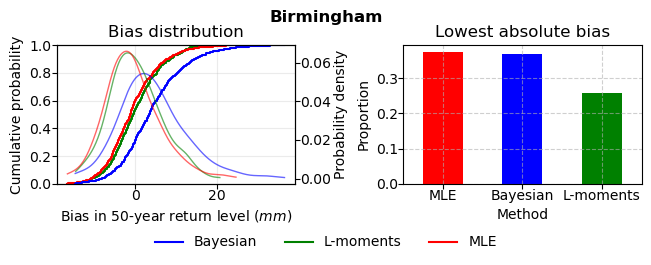



Processing: Little Rock

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     199
L-moments    162
MLE          139
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     199
L-moments    162
MLE          139
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


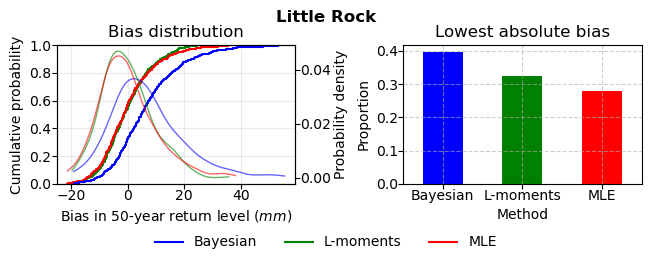



Processing: Phoenix

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     202
L-moments    183
MLE          115
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     202
L-moments    183
MLE          115
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


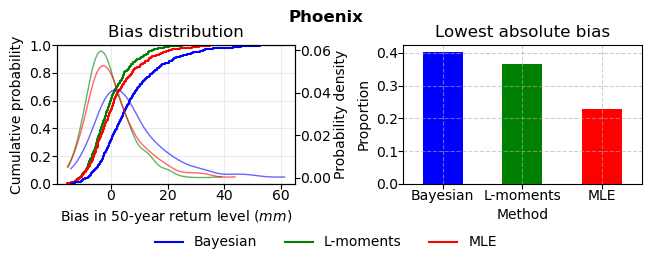



Processing: Los Angeles

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     184
MLE          173
L-moments    130
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     184
MLE          173
L-moments    130
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


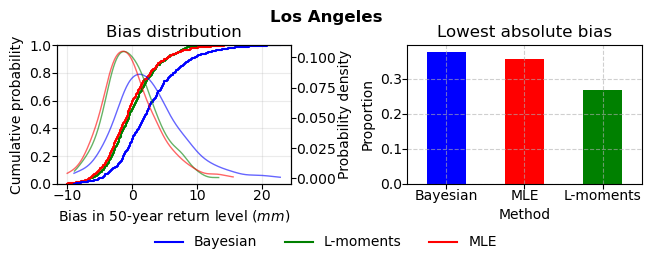



Processing: New York City

=== Lowest absolute bias_t50 (including ties) ===
Bayesian     203
L-moments    182
MLE          115
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     203
L-moments    182
MLE          115
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


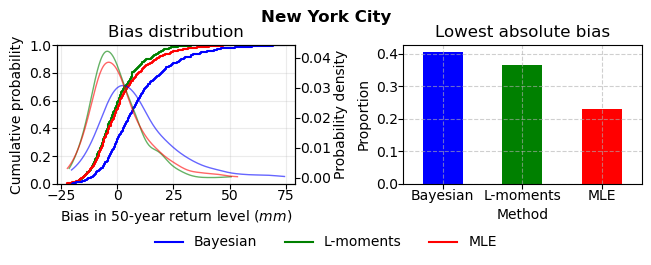

In [286]:
city_names = ["Birmingham", "Little Rock", "Phoenix", "Los Angeles","New York City"] # hartford is wrong

for city_n in city_names:

    print("\n\n============================")
    print("Processing:", city_n)
    print("============================")

    # --- file paths ---
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Stationary\bias_sim_series_{city_n}_N46.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Stationary\bias_sim_series_1hr_Lmoments_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Stationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"

    # --- colors ---
    METHOD_COLORS = {
        "Bayesian": "blue",
        "L-moments": "green",
        "MLE": "red",
    }

    def prep_df(path, label):
        df = pd.read_csv(path)
        col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")
    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)
    bayes_zero_sims = bayes.loc[bayes["bias_t50"] == 0, "sim"]
    all_df = all_df[~all_df["sim"].isin(bayes_zero_sims)]
    # -------------------------
    # Remove simulations with ANY missing method
    # -------------------------
    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    # -------------------------
    # Rebuild pivot
    # -------------------------
    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # -------------------------
    # Sorting
    # -------------------------
    def sim_key(x):
        m = re.search(r"(\d+)", str(x))
        return int(m.group(1)) if m else x

    all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

    # -------------------------
    # Alpha based on bias ranking
    # -------------------------
    min_per_sim = abs_bias.min(axis=1)
    max_per_sim = abs_bias.max(axis=1)

    def alpha_for_row(row):
        sim = row["sim"]
        val = abs(row["bias_t50"])
        if np.isfinite(val):
            if np.isclose(val, min_per_sim.loc[sim]):
                return 1.0
            elif np.isclose(val, max_per_sim.loc[sim]):
                return 0.2
            else:
                return 0.6
        return 0.2

    all_df["alpha"] = all_df.apply(alpha_for_row, axis=1)

    # -------------------------
    # Winner counts
    # -------------------------
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    tie_only = winner_label[~is_single]
    tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

    # -------------------------
    # PRINT RESULTS (RESTORED)
    # -------------------------
    print("\n=== Lowest absolute bias_t50 (including ties) ===")
    print(counts_incl_ties)

    print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
    print(counts_excl_ties)

    print("\n=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===")
    print(tie_sizes)

    # -------------------------
    # FIGURE — 2 panels
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)
    # Reset legend containers here
    handles = []
    labels = []
    # ===============================
    # Panel 1: ECDF + PDF twin axis
    # ===============================
    ax = axes[0]
    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )
    ax.set_xlabel(f"Bias in 50-year return level ($mm$)")
    ax.set_ylabel("Cumulative probability")
    ax.set_title("Bias distribution")
    ax.grid(True, linestyle="-", alpha=0.25)
    ax.tick_params(axis="both", which="major", pad=0)
    ax.legend_.remove()

    # --- twin PDF axis ---
    ax_pdf = ax.twinx()
    ax_pdf.set_ylabel("Probability density", labelpad=2)

    for name, g in all_df.groupby("Method"):
        g = g.dropna(subset=["bias_t50"])
        if len(g) < 2:
            continue

        x = g["bias_t50"].to_numpy()
        kde = gaussian_kde(x)
        xs = np.linspace(x.min(), x.max(), 300)
        pdf = kde(xs)
        ax_pdf.plot(xs, pdf, color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    ax_pdf.tick_params(axis="both", which="major", pad=0)
    ax_pdf.grid(False)


    # ===============================
    # Panel 2: Bar chart of winners (proportions)
    # ===============================
    ax = axes[1]

    # convert counts → proportions
    proportions = counts_excl_ties / counts_excl_ties.sum()

    bar_colors = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]
    proportions.plot(kind="bar", ax=ax, color=bar_colors)

    ax.set_ylabel("Proportion")
    ax.set_title("Lowest absolute bias")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlabel("Method")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.tick_params(axis="both", which="major", pad=0)

    # ===============================
    # Figure title
    # ===============================
    fig.suptitle(city_n, fontsize=12, fontweight="bold", y=1.05)

    for name, color in METHOD_COLORS.items():

        # one line handle
        line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)


        # combine them into a single legend entry
        combo = ( line_h)

        handles.append(combo)
        labels.append(name)

    fig.legend(handles, labels,
            handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)},
            loc='lower center',
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, -0.15))
    plt.savefig(fr'D:\BMM-IDF4Drainage_data_results\Bias\Figures\Stationary\{city_n}.jpeg',dpi=300,bbox_inches="tight")
    plt.show()

### One plot

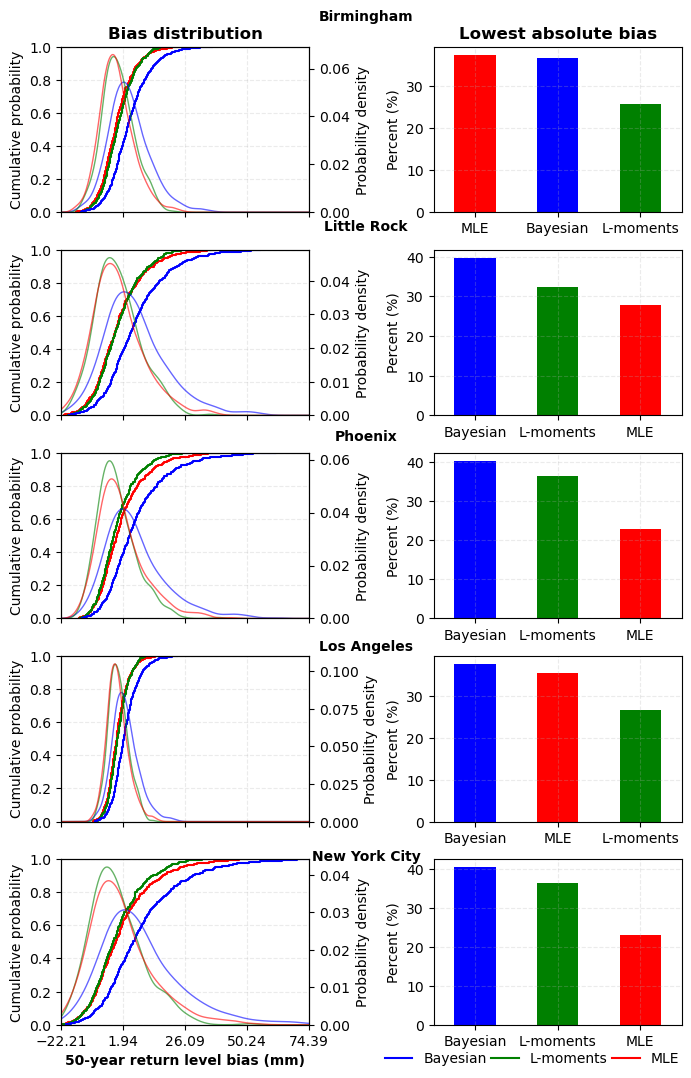

In [346]:
city_names = ["Birmingham", "Little Rock", "Phoenix", "Los Angeles","New York City"]

# -----------------------------------------
# STORAGE for each city's processed results
# -----------------------------------------
ALL_all_df         = []
ALL_counts_excl    = []
ALL_method_colors  = []
ALL_city_names     = []

for city_n in city_names:

    # --- file paths ---
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Stationary\bias_sim_series_{city_n}_N46.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Stationary\bias_sim_series_1hr_Lmoments_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Stationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"

    METHOD_COLORS = {"Bayesian": "blue","L-moments": "green","MLE": "red"}

    def prep_df(path, label):
        df = pd.read_csv(path)
        col_b = next(c for c in df.columns if c.lower() == "bias_t50")
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_b], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")

    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)
    bayes_zero = bayes.loc[bayes["bias_t50"] == 0, "sim"]
    all_df = all_df[~all_df["sim"].isin(bayes_zero)]

    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # ranking winner counts
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    # ------------------
    # STORE RESULTS
    # ------------------
    ALL_all_df.append(all_df)
    ALL_counts_excl.append(counts_excl_ties)
    ALL_method_colors.append(METHOD_COLORS)
    ALL_city_names.append(city_n)

# ============================================================
#  NOW MAKE ONE BIG FIGURE
# ============================================================
# --------------------------------------------------------
# Compute GLOBAL min/max for bias_t50 across all cities
# --------------------------------------------------------
global_min = min(df["bias_t50"].min() for df in ALL_all_df)
global_max = max(df["bias_t50"].max() for df in ALL_all_df)

# Optional: choose the number of ticks (5 is common)
xticks = np.linspace(global_min, global_max, 5)

fig, axes = plt.subplots(
    len(city_names), 2,
    figsize=(8*0.85, 3*0.7*len(city_names)),
    constrained_layout=True
)

for i, city_n in enumerate(city_names):

    all_df        = ALL_all_df[i]
    counts_excl   = ALL_counts_excl[i]
    METHOD_COLORS = ALL_method_colors[i]

    # -----------------------------------
    # Panel 1 — ECDF + PDF
    # -----------------------------------
    ax = axes[i, 0]

    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )

    # ---------- SAME X-AXIS TICKS FOR ALL ROWS ----------
    ax.set_xlim(global_min, global_max)
    ax.set_xticks(xticks)

    # ----- Show tick labels only for last row -----
    if i == len(city_names) - 1:
            ax.set_xlabel("50-year return level bias (mm)", fontweight="bold")

    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    ax.set_title("")
    ax.legend_.remove()
    ax.grid(True, linestyle="--", alpha=0.25)
    if i == 0:
        ax.set_title("Bias distribution", fontsize=12, fontweight="bold")

    # ---------- PDF twin axis ----------
    ax_pdf = ax.twinx()
    for name, g in all_df.groupby("Method"):
        x = g["bias_t50"].dropna().to_numpy()
        if len(x) < 2:
            continue
        kde = gaussian_kde(x)
        xs = np.linspace(global_min, global_max, 300)   # match global range
        ax_pdf.plot(xs, kde(xs), color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    ax_pdf.set_ylim(bottom=0)   # optional
    ax_pdf.grid(False)
    ax.set_ylabel("Cumulative probability")   # CDF axis
    ax_pdf.set_ylabel("Probability density")   # PDF axis
    


    # -----------------------------------
    # Panel 2 — winner proportions
    # -----------------------------------
    ax2 = axes[i, 1]

    proportions = counts_excl / counts_excl.sum()*100
    bar_colors  = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]

    proportions.plot(kind="bar", ax=ax2, color=bar_colors)
    ax2.set_title("")
    ax2.grid(True, linestyle="--", alpha=0.25)
    ax2.set_xlabel("")
    ax2.set_ylabel('Percent (%)')
    ax2.tick_params(axis='x', labelrotation=0)
    if i == 0:
        ax2.set_title("Lowest absolute bias", fontsize=12, fontweight="bold")


    # ------------------------------------------
    # Add centered bold city label for this row
    # ------------------------------------------
    row_top = 1 - (i) / len(city_names)

    fig.text(
        0.53, row_top+0.012 , city_n,
        ha='center', va='top',
        fontsize=10, fontweight='bold'
    )

# final legend
handles = [plt.Line2D([], [], color=c, linewidth=1.5)
           for c in METHOD_COLORS.values()]
labels = METHOD_COLORS.keys()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=3,
    frameon=False,
    markerscale=0.3,      # smaller handles
    columnspacing=0.3     # tighter spacing between columns
)
plt.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Bias\Figures\Stationary\ALL_CITIES_ST.jpeg",
    dpi=300, bbox_inches="tight"
)
plt.show()


### Noisy Stationary


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     196
MLE          168
L-moments    126
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     196
MLE          168
L-moments    126
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


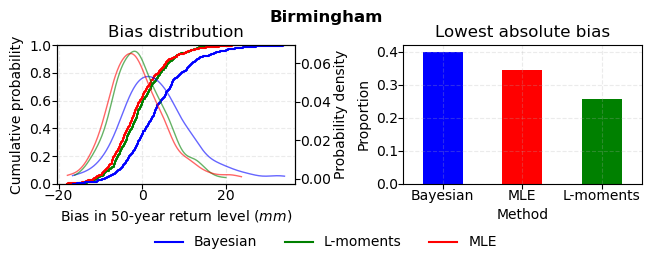


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     210
L-moments    165
MLE          125
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     210
L-moments    165
MLE          125
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


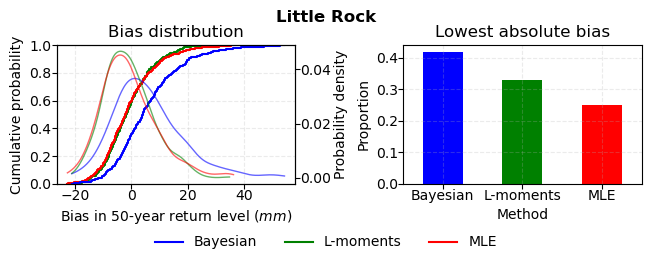


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     208
L-moments    172
MLE          120
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     208
L-moments    172
MLE          120
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


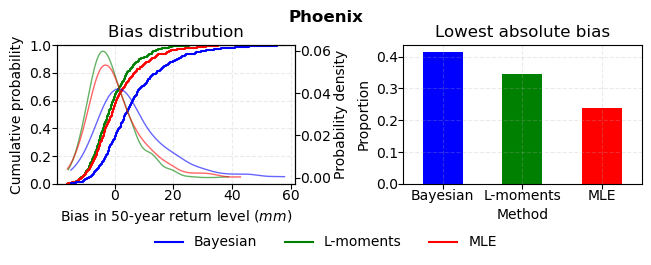


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     200
MLE          157
L-moments    132
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     200
MLE          157
L-moments    132
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


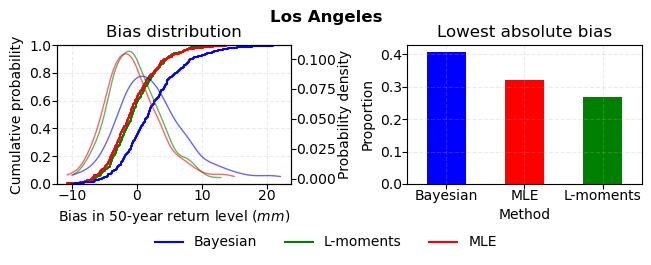


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     205
L-moments    173
MLE          122
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     205
L-moments    173
MLE          122
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


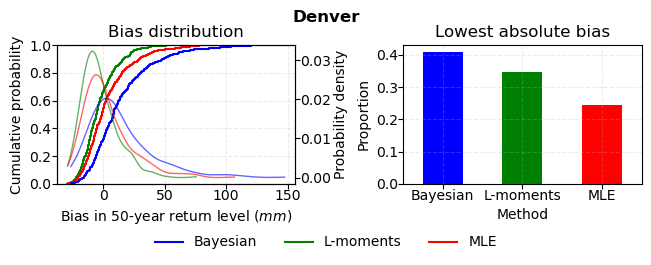


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     209
L-moments    171
MLE          120
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     209
L-moments    171
MLE          120
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


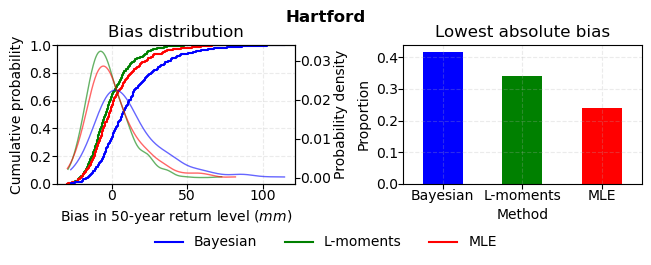


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     210
L-moments    158
MLE          131
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     210
L-moments    158
MLE          131
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


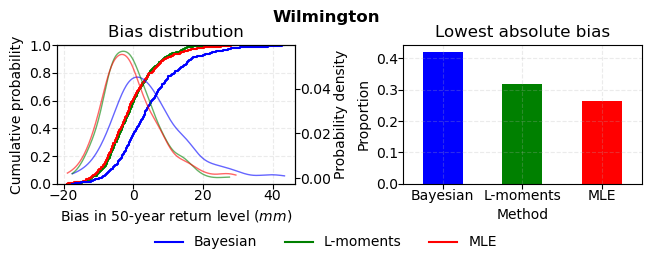


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     189
L-moments    153
MLE          114
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     189
L-moments    153
MLE          114
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


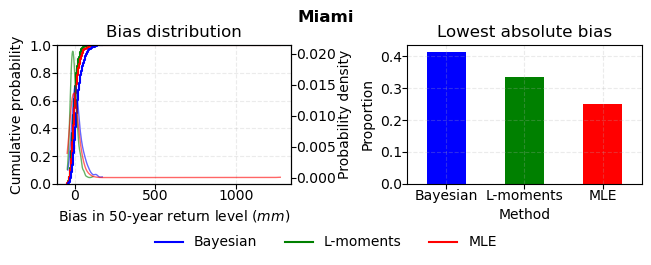

In [347]:
# --- file paths for stationary NYC ---
city_names=["Birmingham","Little Rock","Phoenix","Los Angeles","Denver","Hartford","Wilmington","Miami"]
for city_n in city_names:
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Noise_stationary\bias_sim_series_{city_n}_N46.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Noise_stationary\bias_sim_series_1hr_Lmoments_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Noise_stationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"
    # --- requested colors ---
    MLE_COLOR      = "red"
    MOM_COLOR      = "green"
    Beysian_color  = "blue"  

    METHOD_COLORS = {
        "Bayesian": Beysian_color,
        "L-moments": MOM_COLOR,
        "MLE": MLE_COLOR,
    }

    def prep_df(path, label):
        df = pd.read_csv(path)
        # find 'bias_t50' column (case-insensitive)
        col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")
    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

    # -------------------------
    # Remove simulations with ANY missing method
    # -------------------------
    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    # -------------------------
    # Rebuild pivot
    # -------------------------
    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # -------------------------
    # Sorting
    # -------------------------
    def sim_key(x):
        m = re.search(r"(\d+)", str(x))
        return int(m.group(1)) if m else x

    all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

    # -------------------------
    # Alpha based on bias ranking
    # -------------------------
    min_per_sim = abs_bias.min(axis=1)
    max_per_sim = abs_bias.max(axis=1)

    def alpha_for_row(row):
        sim = row["sim"]
        val = abs(row["bias_t50"])
        if np.isfinite(val):
            if np.isclose(val, min_per_sim.loc[sim]):
                return 1.0
            elif np.isclose(val, max_per_sim.loc[sim]):
                return 0.2
            else:
                return 0.6
        return 0.2

    all_df["alpha"] = all_df.apply(alpha_for_row, axis=1)

    # -------------------------
    # Winner counts
    # -------------------------
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    tie_only = winner_label[~is_single]
    tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

    # -------------------------
    # PRINT RESULTS (RESTORED)
    # -------------------------
    print("\n=== Lowest absolute bias_t50 (including ties) ===")
    print(counts_incl_ties)

    print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
    print(counts_excl_ties)

    print("\n=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===")
    print(tie_sizes)

    # -------------------------
    # FIGURE — 2 panels
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)
    # Reset legend containers here
    handles = []
    labels = []
    # ===============================
    # Panel 1: ECDF + PDF twin axis
    # ===============================
    ax = axes[0]
    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )
    ax.set_xlabel(f"Bias in 50-year return level ($mm$)")
    ax.set_ylabel("Cumulative probability")
    ax.set_title("Bias distribution")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", which="major", pad=0)
    ax.legend_.remove()

    # --- twin PDF axis ---
    ax_pdf = ax.twinx()
    ax_pdf.set_ylabel("Probability density", labelpad=2)

    for name, g in all_df.groupby("Method"):
        g = g.dropna(subset=["bias_t50"])
        if len(g) < 2:
            continue

        x = g["bias_t50"].to_numpy()
        kde = gaussian_kde(x)
        xs = np.linspace(x.min(), x.max(), 300)
        pdf = kde(xs)
        ax_pdf.plot(xs, pdf, color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    ax_pdf.tick_params(axis="both", which="major", pad=0)
    ax_pdf.grid(False)


    # ===============================
    # Panel 2: Bar chart of winners (proportions)
    # ===============================
    ax = axes[1]

    # convert counts → proportions
    proportions = counts_excl_ties / counts_excl_ties.sum()

    bar_colors = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]
    proportions.plot(kind="bar", ax=ax, color=bar_colors)

    ax.set_ylabel("Proportion")
    ax.set_title("Lowest absolute bias")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_xlabel("Method")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.tick_params(axis="both", which="major", pad=0)

    # ===============================
    # Figure title
    # ===============================
    fig.suptitle(city_n, fontsize=12, fontweight="bold", y=1.05)

    for name, color in METHOD_COLORS.items():

        # one line handle
        line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)


        # combine them into a single legend entry
        combo = ( line_h)

        handles.append(combo)
        labels.append(name)

    fig.legend(handles, labels,
            handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)},
            loc='lower center',
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, -0.15))
    plt.savefig(fr'D:\BMM-IDF4Drainage_data_results\Bias\Figures\Noisy stationary\{city_n}.jpeg',dpi=300,bbox_inches="tight")
    plt.show()

### One plot

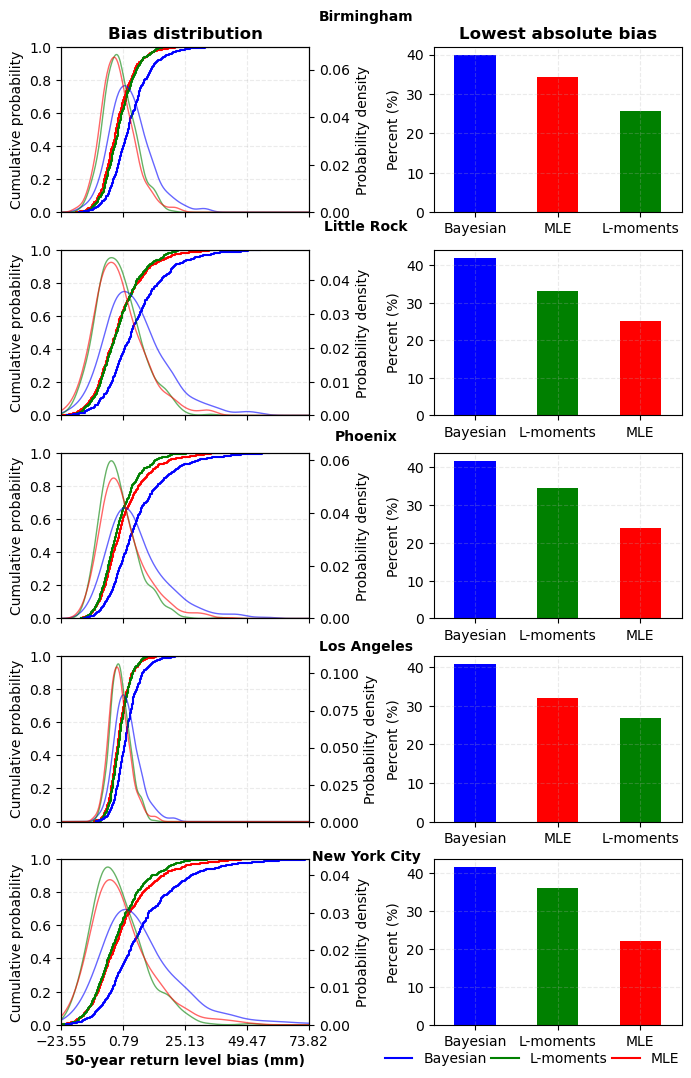

In [348]:
city_names = ["Birmingham", "Little Rock", "Phoenix", "Los Angeles","New York City"]

# -----------------------------------------
# STORAGE for each city's processed results
# -----------------------------------------
ALL_all_df         = []
ALL_counts_excl    = []
ALL_method_colors  = []
ALL_city_names     = []

for city_n in city_names:

    # --- file paths ---
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Noise_stationary\bias_sim_series_{city_n}_N46.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Noise_stationary\bias_sim_series_1hr_Lmoments_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Noise_stationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"

    METHOD_COLORS = {"Bayesian": "blue","L-moments": "green","MLE": "red"}

    def prep_df(path, label):
        df = pd.read_csv(path)
        col_b = next(c for c in df.columns if c.lower() == "bias_t50")
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_b], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")

    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)
    bayes_zero = bayes.loc[bayes["bias_t50"] == 0, "sim"]
    all_df = all_df[~all_df["sim"].isin(bayes_zero)]

    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # ranking winner counts
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    # ------------------
    # STORE RESULTS
    # ------------------
    ALL_all_df.append(all_df)
    ALL_counts_excl.append(counts_excl_ties)
    ALL_method_colors.append(METHOD_COLORS)
    ALL_city_names.append(city_n)

# ============================================================
#  NOW MAKE ONE BIG FIGURE
# ============================================================
# --------------------------------------------------------
# Compute GLOBAL min/max for bias_t50 across all cities
# --------------------------------------------------------
global_min = min(df["bias_t50"].min() for df in ALL_all_df)
global_max = max(df["bias_t50"].max() for df in ALL_all_df)

# Optional: choose the number of ticks (5 is common)
xticks = np.linspace(global_min, global_max, 5)

fig, axes = plt.subplots(
    len(city_names), 2,
    figsize=(8*0.85, 3*0.7*len(city_names)),
    constrained_layout=True
)

for i, city_n in enumerate(city_names):

    all_df        = ALL_all_df[i]
    counts_excl   = ALL_counts_excl[i]
    METHOD_COLORS = ALL_method_colors[i]

    # -----------------------------------
    # Panel 1 — ECDF + PDF
    # -----------------------------------
    ax = axes[i, 0]

    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )

    # ---------- SAME X-AXIS TICKS FOR ALL ROWS ----------
    ax.set_xlim(global_min, global_max)
    ax.set_xticks(xticks)

    # ----- Show tick labels only for last row -----
    if i == len(city_names) - 1:
            ax.set_xlabel("50-year return level bias (mm)", fontweight="bold")

    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    ax.set_title("")
    ax.legend_.remove()
    ax.grid(True, linestyle="--", alpha=0.25)
    if i == 0:
        ax.set_title("Bias distribution", fontsize=12, fontweight="bold")

    # ---------- PDF twin axis ----------
    ax_pdf = ax.twinx()
    for name, g in all_df.groupby("Method"):
        x = g["bias_t50"].dropna().to_numpy()
        if len(x) < 2:
            continue
        kde = gaussian_kde(x)
        xs = np.linspace(global_min, global_max, 300)   # match global range
        ax_pdf.plot(xs, kde(xs), color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    ax_pdf.set_ylim(bottom=0)   # optional
    ax_pdf.grid(False)
    ax.set_ylabel("Cumulative probability")   # CDF axis
    ax_pdf.set_ylabel("Probability density")   # PDF axis
    


    # -----------------------------------
    # Panel 2 — winner proportions
    # -----------------------------------
    ax2 = axes[i, 1]

    proportions = counts_excl / counts_excl.sum()*100
    bar_colors  = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]

    proportions.plot(kind="bar", ax=ax2, color=bar_colors)
    ax2.set_title("")
    ax2.grid(True, linestyle="--", alpha=0.25)
    ax2.set_xlabel("")
    ax2.set_ylabel('Percent (%)')
    ax2.tick_params(axis='x', labelrotation=0)
    if i == 0:
        ax2.set_title("Lowest absolute bias", fontsize=12, fontweight="bold")


    # ------------------------------------------
    # Add centered bold city label for this row
    # ------------------------------------------
    row_top = 1 - (i) / len(city_names)

    fig.text(
        0.53, row_top+0.012 , city_n,
        ha='center', va='top',
        fontsize=10, fontweight='bold'
    )

# final legend
handles = [plt.Line2D([], [], color=c, linewidth=1.5)
           for c in METHOD_COLORS.values()]
labels = METHOD_COLORS.keys()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=3,
    frameon=False,
    markerscale=0.3,      # smaller handles
    columnspacing=0.3     # tighter spacing between columns
)
plt.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Bias\Figures\Noisy stationary\ALL_CITIES_NST.jpeg",
    dpi=300, bbox_inches="tight"
)
plt.show()


### Nonstationary


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     243
MLE          173
L-moments     84
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     243
MLE          173
L-moments     84
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


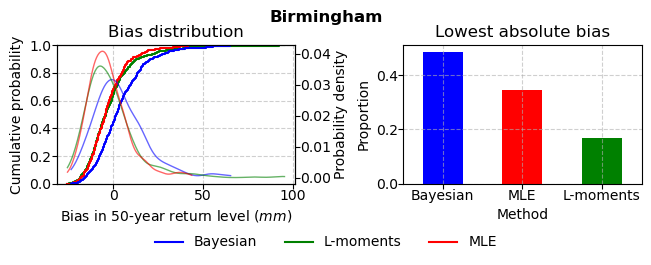


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     217
MLE          194
L-moments     89
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     217
MLE          194
L-moments     89
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


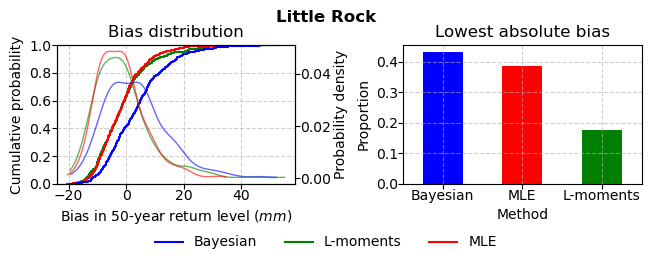


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     204
MLE          156
L-moments    140
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     204
MLE          156
L-moments    140
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


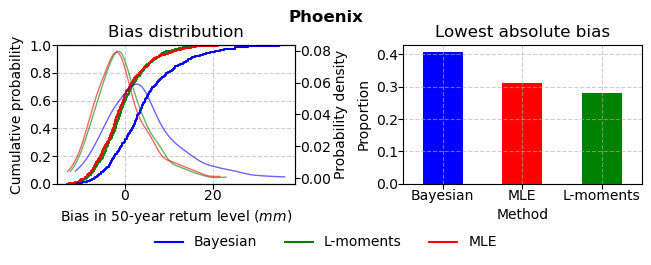


=== Lowest absolute bias_t50 (including ties) ===
Bayesian     217
MLE          167
L-moments    116
Name: count, dtype: int64

=== Lowest absolute bias_t50 (excluding ties) ===
Bayesian     217
MLE          167
L-moments    116
Name: count, dtype: int64

=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===
Series([], Name: count, dtype: int64)


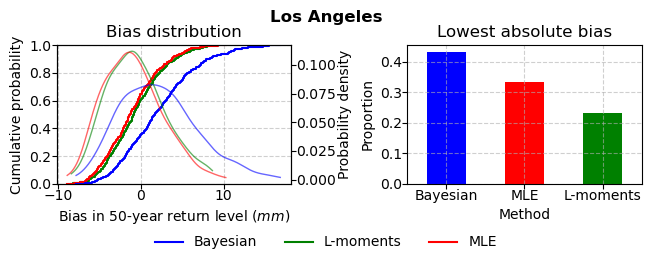

In [ ]:
# --- file paths for stationary NYC ---
city_names=["Birmingham","Little Rock","Phoenix","Los Angeles"]
for city_n in city_names:
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Nonstationary\nonstationary_bias_sim_series_{city_n}.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Nonstationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Nonstationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"
    # --- requested colors ---
    MLE_COLOR      = "red"
    MOM_COLOR      = "green"
    Beysian_color  = "blue"  

    METHOD_COLORS = {
        "Bayesian": Beysian_color,
        "L-moments": MOM_COLOR,
        "MLE": MLE_COLOR,
    }

    def prep_df(path, label):
        df = pd.read_csv(path)
        # find 'bias_t50' column (case-insensitive)
        col_bias_t50 = next((c for c in df.columns if c.lower() == "bias_t50"), None)
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_bias_t50], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")
    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

    # -------------------------
    # Remove simulations with ANY missing method
    # -------------------------
    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    # -------------------------
    # Rebuild pivot
    # -------------------------
    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # -------------------------
    # Sorting
    # -------------------------
    def sim_key(x):
        m = re.search(r"(\d+)", str(x))
        return int(m.group(1)) if m else x

    all_df = all_df.sort_values(by="sim", key=lambda s: s.map(sim_key))

    # -------------------------
    # Alpha based on bias ranking
    # -------------------------
    min_per_sim = abs_bias.min(axis=1)
    max_per_sim = abs_bias.max(axis=1)

    def alpha_for_row(row):
        sim = row["sim"]
        val = abs(row["bias_t50"])
        if np.isfinite(val):
            if np.isclose(val, min_per_sim.loc[sim]):
                return 1.0
            elif np.isclose(val, max_per_sim.loc[sim]):
                return 0.2
            else:
                return 0.6
        return 0.2

    all_df["alpha"] = all_df.apply(alpha_for_row, axis=1)

    # -------------------------
    # Winner counts
    # -------------------------
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    counts_incl_ties = winner_label.value_counts().sort_values(ascending=False)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    tie_only = winner_label[~is_single]
    tie_sizes = tie_only.apply(lambda s: len(s.split("&"))).value_counts().sort_index()

    # -------------------------
    # PRINT RESULTS (RESTORED)
    # -------------------------
    print("\n=== Lowest absolute bias_t50 (including ties) ===")
    print(counts_incl_ties)

    print("\n=== Lowest absolute bias_t50 (excluding ties) ===")
    print(counts_excl_ties)

    print("\n=== Tie size breakdown (how many sims had 2-way, 3-way ties, etc.) ===")
    print(tie_sizes)

    # -------------------------
    # FIGURE — 2 panels
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(8*0.8, 3*0.7), constrained_layout=True)
    # Reset legend containers here
    handles = []
    labels = []
    # ===============================
    # Panel 1: ECDF + PDF twin axis
    # ===============================
    ax = axes[0]
    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )
    ax.set_xlabel(f"Bias in 50-year return level ($mm$)")
    ax.set_ylabel("Cumulative probability")
    ax.set_title("Bias distribution")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", which="major", pad=0)
    ax.legend_.remove()

    # --- twin PDF axis ---
    ax_pdf = ax.twinx()
    ax_pdf.set_ylabel("Probability density", labelpad=2)

    for name, g in all_df.groupby("Method"):
        g = g.dropna(subset=["bias_t50"])
        if len(g) < 2:
            continue

        x = g["bias_t50"].to_numpy()
        kde = gaussian_kde(x)
        xs = np.linspace(x.min(), x.max(), 300)
        pdf = kde(xs)
        ax_pdf.plot(xs, pdf, color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    ax_pdf.tick_params(axis="both", which="major", pad=0)
    ax_pdf.grid(False)


    # ===============================
    # Panel 2: Bar chart of winners (proportions)
    # ===============================
    ax = axes[1]

    # convert counts → proportions
    proportions = counts_excl_ties / counts_excl_ties.sum()

    bar_colors = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]
    proportions.plot(kind="bar", ax=ax, color=bar_colors)

    ax.set_ylabel("Proportion")
    ax.set_title("Lowest absolute bias")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlabel("Method")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.tick_params(axis="both", which="major", pad=0)

    # ===============================
    # Figure title
    # ===============================
    fig.suptitle(city_n, fontsize=12, fontweight="bold", y=1.05)

    for name, color in METHOD_COLORS.items():

        # one line handle
        line_h = plt.Line2D([], [], color=color, linestyle='-', linewidth=1.5)


        # combine them into a single legend entry
        combo = ( line_h)

        handles.append(combo)
        labels.append(name)

    fig.legend(handles, labels,
            handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple(ndivide=None)},
            loc='lower center',
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, -0.15))
    plt.savefig(fr'D:\BMM-IDF4Drainage_data_results\Bias\Figures\Nonstationary\{city_n}.jpeg',dpi=300,bbox_inches="tight")
    plt.show()

### One plot

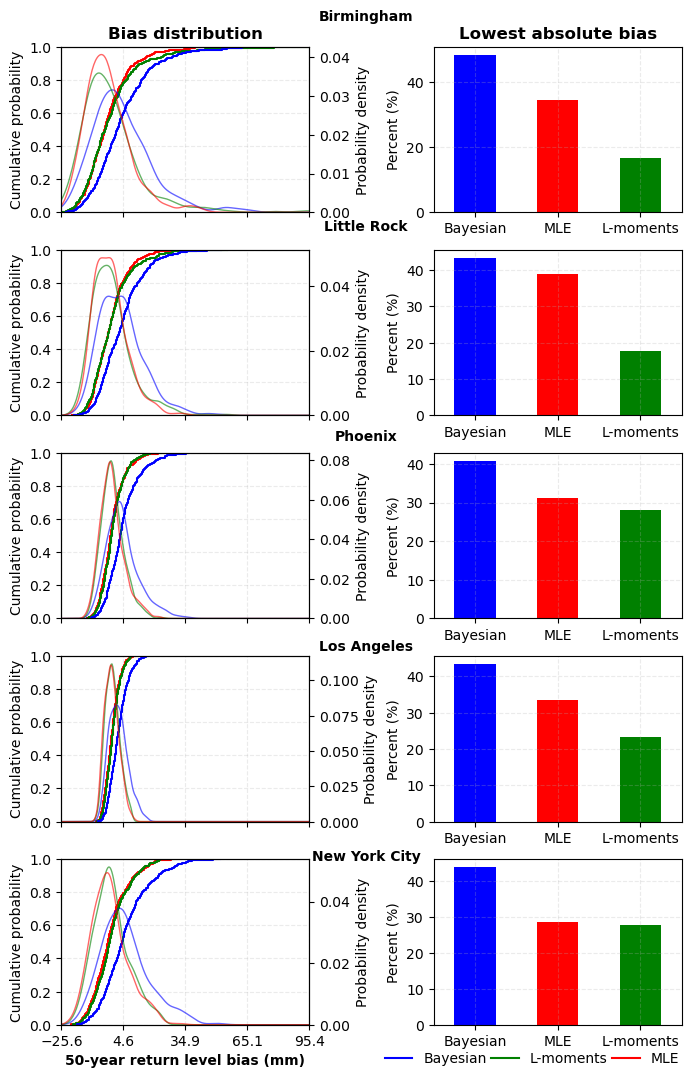

In [349]:
city_names = ["Birmingham", "Little Rock", "Phoenix", "Los Angeles","New York City"]

# -----------------------------------------
# STORAGE for each city's processed results
# -----------------------------------------
ALL_all_df         = []
ALL_counts_excl    = []
ALL_method_colors  = []
ALL_city_names     = []

for city_n in city_names:

    # --- file paths ---
    p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Nonstationary\nonstationary_bias_sim_series_{city_n}.csv"
    p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Nonstationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"
    p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Nonstationary\bias_sim_series_1hr_MLE_{city_n}_N46.csv"

    METHOD_COLORS = {"Bayesian": "blue","L-moments": "green","MLE": "red"}

    def prep_df(path, label):
        df = pd.read_csv(path)
        col_b = next(c for c in df.columns if c.lower() == "bias_t50")
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_b], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom,  "L-moments")
    mle   = prep_df(p_mle,   "MLE")

    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)
    bayes_zero = bayes.loc[bayes["bias_t50"] == 0, "sim"]
    all_df = all_df[~all_df["sim"].isin(bayes_zero)]

    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    abs_bias = pivot.abs()

    # ranking winner counts
    row_mins = abs_bias.min(axis=1)
    winners_mask = abs_bias.eq(row_mins, axis=0)
    winner_label = winners_mask.apply(lambda r: "&".join(r.index[r]), axis=1)

    is_single = ~winner_label.str.contains("&")
    counts_excl_ties = winner_label[is_single].value_counts().sort_values(ascending=False)

    # ------------------
    # STORE RESULTS
    # ------------------
    ALL_all_df.append(all_df)
    ALL_counts_excl.append(counts_excl_ties)
    ALL_method_colors.append(METHOD_COLORS)
    ALL_city_names.append(city_n)

# ============================================================
#  NOW MAKE ONE BIG FIGURE
# ============================================================
# --------------------------------------------------------
# Compute GLOBAL min/max for bias_t50 across all cities
# --------------------------------------------------------
global_min = min(df["bias_t50"].min() for df in ALL_all_df)
global_max = max(df["bias_t50"].max() for df in ALL_all_df)

# Optional: choose the number of ticks (5 is common)
xticks = np.linspace(global_min, global_max, 5)

fig, axes = plt.subplots(
    len(city_names), 2,
    figsize=(8*0.85, 3*0.7*len(city_names)),
    constrained_layout=True
)

for i, city_n in enumerate(city_names):

    all_df        = ALL_all_df[i]
    counts_excl   = ALL_counts_excl[i]
    METHOD_COLORS = ALL_method_colors[i]

    # -----------------------------------
    # Panel 1 — ECDF + PDF
    # -----------------------------------
    ax = axes[i, 0]

    sns.ecdfplot(
        data=all_df,
        x="bias_t50",
        hue="Method",
        palette=METHOD_COLORS,
        ax=ax
    )

    # ---------- SAME X-AXIS TICKS FOR ALL ROWS ----------
    ax.set_xlim(global_min, global_max)
    ax.set_xticks(xticks)

    # ----- Show tick labels only for last row -----
    if i == len(city_names) - 1:
            ax.set_xlabel("50-year return level bias (mm)", fontweight="bold")

    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

    ax.set_title("")
    ax.legend_.remove()
    ax.grid(True, linestyle="--", alpha=0.25)
    if i == 0:
        ax.set_title("Bias distribution", fontsize=12, fontweight="bold")

    # ---------- PDF twin axis ----------
    ax_pdf = ax.twinx()
    for name, g in all_df.groupby("Method"):
        x = g["bias_t50"].dropna().to_numpy()
        if len(x) < 2:
            continue
        kde = gaussian_kde(x)
        xs = np.linspace(global_min, global_max, 300)   # match global range
        ax_pdf.plot(xs, kde(xs), color=METHOD_COLORS[name], linewidth=1, alpha=0.6)

    ax_pdf.set_ylim(bottom=0)   # optional
    ax_pdf.grid(False)
    ax.set_ylabel("Cumulative probability")   # CDF axis
    ax_pdf.set_ylabel("Probability density")   # PDF axis
    


    # -----------------------------------
    # Panel 2 — winner proportions
    # -----------------------------------
    ax2 = axes[i, 1]

    proportions = counts_excl / counts_excl.sum()*100
    bar_colors  = [METHOD_COLORS.get(m, "0.5") for m in proportions.index]

    proportions.plot(kind="bar", ax=ax2, color=bar_colors)
    ax2.set_title("")
    ax2.grid(True, linestyle="--", alpha=0.25)
    ax2.set_xlabel("")
    ax2.set_ylabel('Percent (%)')
    ax2.tick_params(axis='x', labelrotation=0)
    if i == 0:
        ax2.set_title("Lowest absolute bias", fontsize=12, fontweight="bold")


    # ------------------------------------------
    # Add centered bold city label for this row
    # ------------------------------------------
    row_top = 1 - (i) / len(city_names)

    fig.text(
        0.53, row_top+0.012 , city_n,
        ha='center', va='top',
        fontsize=10, fontweight='bold'
    )

# final legend
handles = [plt.Line2D([], [], color=c, linewidth=1.5)
           for c in METHOD_COLORS.values()]
labels = METHOD_COLORS.keys()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=3,
    frameon=False,
    markerscale=0.3,      # smaller handles
    columnspacing=0.3     # tighter spacing between columns
)
plt.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Bias\Figures\Nonstationary\ALL_CITIES_NNST.jpeg",
    dpi=300, bbox_inches="tight"
)
plt.show()


## Stationary noisy-stationary and nonstatioanry in one plot

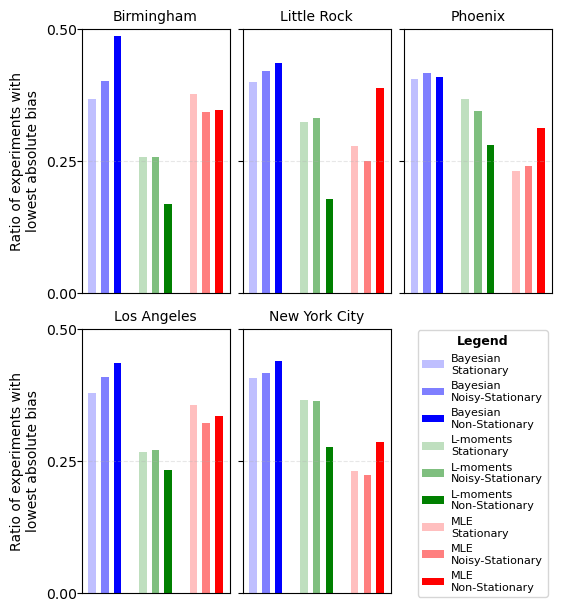

In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ================================================================
# CONFIG
# ================================================================
CITIES = ["Birmingham", "Little Rock", "Phoenix", "Los Angeles", "New York City"]

METHOD_COLORS = {
    "Bayesian": "blue",
    "L-moments": "green",
    "MLE": "red",
}

COLUMN_TITLES = ["Stationary", "Noisy-Stationary", "Non-Stationary"]
conditions = ["stationary", "noisy", "nonstationary"]
condition_alpha = [0.25, 0.5, 1.0]


# ================================================================
# Helper: compute winner proportions
# ================================================================
def compute_proportions(city, condition):

    if condition == "stationary":
        p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Stationary\bias_sim_series_{city}_N46.csv"
        p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Stationary\bias_sim_series_1hr_Lmoments_{city}_N46.csv"
        p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Stationary\bias_sim_series_1hr_MLE_{city}_N46.csv"

    elif condition == "noisy":
        p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Noise_stationary\bias_sim_series_{city}_N46.csv"
        p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Noise_stationary\bias_sim_series_1hr_Lmoments_{city}_N46.csv"
        p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Noise_stationary\bias_sim_series_1hr_MLE_{city}_N46.csv"

    elif condition == "nonstationary":
        p_bayes = fr"D:\BMM-IDF4Drainage_data_results\Bias\Bayesian\bias_series\Nonstationary\nonstationary_bias_sim_series_{city}.csv"
        p_lmom  = fr"D:\BMM-IDF4Drainage_data_results\Bias\L_moments\bias_series\Nonstationary\bias_sim_series_1hr_MLE_{city}_N46.csv"
        p_mle   = fr"D:\BMM-IDF4Drainage_data_results\Bias\MLE\bias_series\Nonstationary\bias_sim_series_1hr_MLE_{city}_N46.csv"

    def prep_df(path, label):
        df = pd.read_csv(path)
        col_bias = next((c for c in df.columns if c.lower() == "bias_t50"), None)
        out = df[["sim"]].copy()
        out["bias_t50"] = pd.to_numeric(df[col_bias], errors="coerce")
        out["Method"] = label
        return out

    bayes = prep_df(p_bayes, "Bayesian")
    lmom  = prep_df(p_lmom, "L-moments")
    mle   = prep_df(p_mle, "MLE")

    all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

    pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
    valid_sims = pivot_raw.dropna().index
    all_df = all_df[all_df["sim"].isin(valid_sims)]

    pivot = all_df.pivot(index="sim", columns="Method", values="bias_t50").abs()

    row_mins = pivot.min(axis=1)
    winners = pivot.eq(row_mins, axis=0)

    labels = winners.apply(lambda r: "&".join(r.index[r]), axis=1)
    single = labels[~labels.str.contains("&")]

    counts = single.value_counts()

    for m in ["Bayesian", "L-moments", "MLE"]:
        if m not in counts:
            counts[m] = 0

    counts = counts.sort_index()
    return counts / counts.sum()


# ================================================================
# Create 2×3 figure
# ================================================================
fig, axes = plt.subplots(2, 3, figsize=(5.5, 6.0), constrained_layout=True)
axes = axes.flatten()

YTICKS = [0, 0.25, 0.5]

for r, city in enumerate(CITIES):

    ax = axes[r]

    prop_list = [compute_proportions(city, cond) for cond in conditions]
    df_plot = pd.DataFrame(prop_list, index=COLUMN_TITLES).T

    x = np.arange(len(df_plot.index))
    width = 0.15
    spacing = 0.10

    for i, col in enumerate(df_plot.columns):
        ax.bar(
            x + i * (width + spacing),
            df_plot[col].values,
            width=width,
            color=[METHOD_COLORS[m] for m in df_plot.index],
            alpha=condition_alpha[i],
        )

    # Always gridlines
    ax.set_yticks(YTICKS)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # Only show tick labels on first column (r=0 and r=3)
    if r not in [0, 3]:
        ax.set_yticklabels([])

    ax.set_ylim(0, 0.5)
    ax.set_xticks([])

    # y-axis label only for first column
    if r in [0, 3]:
        ax.set_ylabel("Ratio of experiments with\nlowest absolute bias", fontsize=10)

    ax.set_title(city, fontsize=10)
    ax.tick_params(axis="both", which="major", pad=0)

# Turn off 6th subplot
axes[-1].axis("off")


# ================================================================
# Legend
# ================================================================
legend_handles = []
legend_labels = []
process_names = ["Stationary", "Noisy-Stationary", "Non-Stationary"]

for method in METHOD_COLORS:
    for alpha, proc in zip(condition_alpha, process_names):
        legend_handles.append(Patch(facecolor=METHOD_COLORS[method], alpha=alpha))
        legend_labels.append(f"{method}\n{proc}")

lgd = fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Legend",
    loc="lower right",
    bbox_to_anchor=(0.995, 0.005),
    fontsize=8,
    title_fontsize=9,
    ncol=1,
    columnspacing=1.2,
    handletextpad=0.6
)

lgd.get_title().set_fontweight("bold")

# Save
plt.savefig(
    r'D:\BMM-IDF4Drainage_data_results\Figure\numerical_experiments.jpeg',
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### interperet the resutls

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# Config (use yours)
# ----------------------------
DGP_CONFIG = {
    "stationary": {
        "folder": "Stationary",
        "cities": ["Birmingham", "Little Rock", "Phoenix", "Los Angeles", "New York City"],
    },
    "noisy_stationary": {
        "folder": "Noise_stationary",
        "cities": ["Birmingham", "Little Rock", "Phoenix", "Los Angeles", "New York City"],
    },
    "noisy_nonstationary": {
        "folder": "Nonstationary",
        "cities": ["Birmingham", "Little Rock", "Phoenix", "Los Angeles", "New York City"],
    },
}

BASE_DIR = Path(r"D:\BMM-IDF4Drainage_data_results\Bias")

def paths_for_city(folder: str, city: str):
    # Defaults
    p_bayes = BASE_DIR / "Bayesian"  / "bias_series" / folder / f"bias_sim_series_{city}_N46.csv"
    p_lmom  = BASE_DIR / "L_moments" / "bias_series" / folder / f"bias_sim_series_1hr_Lmoments_{city}_N46.csv"
    p_mle   = BASE_DIR / "MLE"       / "bias_series" / folder / f"bias_sim_series_1hr_MLE_{city}_N46.csv"

    # Nonstationary special cases
    if folder.lower() in ["nonstationary", "noisy_nonstationary"]:
        p_bayes = BASE_DIR / "Bayesian" / "bias_series" / folder / f"nonstationary_bias_sim_series_{city}.csv"
        p_lmom  = BASE_DIR / "L_moments" / "bias_series" / folder / f"bias_sim_series_1hr_MLE_{city}_N46.csv"
        p_mle   = BASE_DIR / "MLE" / "bias_series" / folder / f"bias_sim_series_1hr_MLE_{city}_N46.csv"

    return str(p_bayes), str(p_lmom), str(p_mle)

# ----------------------------
# Read one file into sim/bias/Method
# ----------------------------
def prep_df(path, label):
    df = pd.read_csv(path)
    col_b = next(c for c in df.columns if c.lower() == "bias_t50")
    out = df[["sim"]].copy()
    out["bias_t50"] = pd.to_numeric(df[col_b], errors="coerce")
    out["Method"] = label
    return out

# ----------------------------
# Main loop: compute CDF(0) and export per-experiment dataset
# ----------------------------
all_experiments = []
summary = []

for dgp_key, cfg in DGP_CONFIG.items():
    folder = cfg["folder"]

    for city in cfg["cities"]:
        p_bayes, p_lmom, p_mle = paths_for_city(folder, city)

        bayes = prep_df(p_bayes, "Bayesian")
        lmom  = prep_df(p_lmom,  "L-moments")
        mle   = prep_df(p_mle,   "MLE")

        all_df = pd.concat([bayes, lmom, mle], ignore_index=True)

        # ============================================================
        # YOUR EXACT CLEANING SNIPPET
        # ============================================================
        # 1) drop sims where Bayesian bias == 0
        bayes_zero = bayes.loc[bayes["bias_t50"] == 0, "sim"]
        all_df = all_df[~all_df["sim"].isin(bayes_zero)]

        # 2) keep only sims with all methods available
        pivot_raw = all_df.pivot(index="sim", columns="Method", values="bias_t50")
        pivot_raw = pivot_raw[["Bayesian", "MLE", "L-moments"]]
        valid_sims = pivot_raw.dropna().index
        pivot = pivot_raw.loc[valid_sims].copy()
        # ============================================================

        # ---- CDF at 0 for each method (empirical F(0)=P(bias<=0)) ----
        # If you want strict underestimation only, use < 0 instead of <= 0.
        cdf0_bayes = float((pivot["Bayesian"]  < 0).mean()) if len(pivot) else np.nan
        cdf0_mle   = float((pivot["MLE"]       < 0).mean()) if len(pivot) else np.nan
        cdf0_lmom  = float((pivot["L-moments"] < 0).mean()) if len(pivot) else np.nan

        # ---- per-experiment dataset (one row per sim) ----
        df_city = pivot.reset_index()  # sim + 3 method columns
        df_city["dgp"] = dgp_key
        df_city["City"] = city
        df_city["cdf0_Bayesian"] = cdf0_bayes
        df_city["cdf0_MLE"] = cdf0_mle
        df_city["cdf0_Lmoments"] = cdf0_lmom

        all_experiments.append(df_city)

        # ---- city-level summary table ----
        n_sims = int(len(pivot))
        summary.append({"dgp": dgp_key, "City": city, "Method": "Bayesian",  "n_sims": n_sims, "cdf_at_0": cdf0_bayes})
        summary.append({"dgp": dgp_key, "City": city, "Method": "MLE",       "n_sims": n_sims, "cdf_at_0": cdf0_mle})
        summary.append({"dgp": dgp_key, "City": city, "Method": "L-moments", "n_sims": n_sims, "cdf_at_0": cdf0_lmom})

# Final outputs
df_all = pd.concat(all_experiments, ignore_index=True) if all_experiments else pd.DataFrame()
df_summary = pd.DataFrame(summary)

print("\n=== City-level CDF at 0 (F(0)=P(bias_t50<=0)) ===")
print(df_summary.to_string(index=False))

print("\n=== Per-experiment dataset (first 25 rows) ===")
print(df_all.head(25).to_string(index=False))

# Save
out_dir = Path(r"D:\BMM-IDF4Drainage_data_results\Bias\Figures")
out_dir.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(out_dir / "bias_cdf0_summary_by_city_method.csv", index=False)
df_all.to_csv(out_dir / "bias_per_experiment_with_cdf0.csv", index=False)

print("\nSaved:")
print(" -", out_dir / "bias_cdf0_summary_by_city_method.csv")
print(" -", out_dir / "bias_per_experiment_with_cdf0.csv")


In [55]:
import numpy as np
import pandas as pd

# df_summary columns: dgp, City, Method, n_sims, cdf_at_0
df_s = df_summary.copy()
df_s["cdf_at_0"] = pd.to_numeric(df_s["cdf_at_0"], errors="coerce")

# If cdf_at_0 is fraction (0-1), convert to percent (0-100)
mx = df_s["cdf_at_0"].max()
if pd.notna(mx) and mx <= 1.0:
    df_s["cdf0_pct"] = 100.0 * df_s["cdf_at_0"]
else:
    df_s["cdf0_pct"] = df_s["cdf_at_0"]

# City-level wide table
wide = (
    df_s.pivot_table(index=["dgp", "City"], columns="Method", values="cdf0_pct", aggfunc="first")
      .reset_index()
)

if "L-moments" in wide.columns:
    wide = wide.rename(columns={"L-moments": "Lmoments"})

# Absolute differences (percentage points): baseline - Bayesian
wide["absdiff_pp_Bayes_less_than_MLE"]  = wide["MLE"]      - wide["Bayesian"]
wide["absdiff_pp_Bayes_less_than_Lmom"] = wide["Lmoments"] - wide["Bayesian"]

def boot_ci_mean(x, n_boot=10000, ci=0.95, seed=123):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True)
    means = boots.mean(axis=1)
    alpha = 1 - ci
    return float(x.mean()), float(np.quantile(means, alpha/2)), float(np.quantile(means, 1 - alpha/2))

print("\n=== Manuscript-ready summary with CIs (across cities) ===")

for dgp in wide["dgp"].unique():
    sub = wide[wide["dgp"] == dgp].copy()

    # Mean P(bias<=0) with CI for each method
    b_pt,  b_lo,  b_hi  = boot_ci_mean(sub["Bayesian"],  seed=1000 + (hash((dgp,"B")) % 1000))
    m_pt,  m_lo,  m_hi  = boot_ci_mean(sub["MLE"],       seed=2000 + (hash((dgp,"M")) % 1000))
    l_pt,  l_lo,  l_hi  = boot_ci_mean(sub["Lmoments"],  seed=3000 + (hash((dgp,"L")) % 1000))

    # Mean absolute differences (pp) with CI
    dBM_pt, dBM_lo, dBM_hi = boot_ci_mean(sub["absdiff_pp_Bayes_less_than_MLE"],
                                          seed=4000 + (hash((dgp,"dBM")) % 1000))
    dBL_pt, dBL_lo, dBL_hi = boot_ci_mean(sub["absdiff_pp_Bayes_less_than_Lmom"],
                                          seed=5000 + (hash((dgp,"dBL")) % 1000))

    print(f"\n[{dgp}]")
    print(
        "Mean P(bias<=0) across cities (95% CI): "
        f"Bayesian={b_pt:.1f}% ({b_lo:.1f}–{b_hi:.1f}), "
        f"MLE={m_pt:.1f}% ({m_lo:.1f}–{m_hi:.1f}), "
        f"L-moments={l_pt:.1f}% ({l_lo:.1f}–{l_hi:.1f})."
    )
    print(
        f"Bayesian underestimates {dBM_pt:.1f} percentage points less than MLE "
        f"(95% CI: {dBM_lo:.1f}–{dBM_hi:.1f} pp)."
    )
    print(
        f"Bayesian underestimates {dBL_pt:.1f} percentage points less than L-moments "
        f"(95% CI: {dBL_lo:.1f}–{dBL_hi:.1f} pp)."
    )



=== Manuscript-ready summary with CIs (across cities) ===

[noisy_nonstationary]
Mean P(bias<=0) across cities (95% CI): Bayesian=37.3% (33.4–41.6), MLE=64.9% (63.8–66.6), L-moments=61.7% (60.0–63.6).
Bayesian underestimates 27.6 percentage points less than MLE (95% CI: 24.0–30.8 pp).
Bayesian underestimates 24.4 percentage points less than L-moments (95% CI: 22.1–26.6 pp).

[noisy_stationary]
Mean P(bias<=0) across cities (95% CI): Bayesian=34.7% (33.6–35.7), MLE=59.6% (57.4–61.7), L-moments=60.1% (58.8–61.5).
Bayesian underestimates 24.9 percentage points less than MLE (95% CI: 23.7–26.0 pp).
Bayesian underestimates 25.4 percentage points less than L-moments (95% CI: 23.2–28.0 pp).

[stationary]
Mean P(bias<=0) across cities (95% CI): Bayesian=31.3% (30.9–31.8), MLE=56.4% (53.9–58.9), L-moments=56.0% (53.6–58.5).
Bayesian underestimates 25.1 percentage points less than MLE (95% CI: 22.6–27.7 pp).
Bayesian underestimates 24.7 percentage points less than L-moments (95% CI: 22.3–27.4 p

# Data, MOM, MLE, Bayesian (every city)
## 1hr 

In [5]:
import matplotlib.pyplot as plt
plt.style.use('default')   # <-- resets to plain Matplotlib look

In [ ]:
# --- load MLE params (CSV) ---
mle_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_1h_mle_AORC.csv')
mom_params=pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv')

# --- load your saved posterior samples ---
sample_1h_aorc = np.load(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz")
save_samples_1h = sample_1h_aorc["saved_samples_1h_AORC"]

# pick a city index
i = 29  # <-- change this to the city you want
i = 3  # <-- change this to the city you want

# map your saved arrays to parameter names (from your code’s assignment order)
xi_s    = save_samples_1h[i, 0, :]   # ξ (shape)
mu_s    = save_samples_1h[i, 1, :]   # μ (location)
sigma_s = save_samples_1h[i, 2, :]   # σ (scale)


# subset for plotting to keep it snappy
K = min(2000, xi_s.size)
rng = np.random.default_rng(12345)
idx = rng.choice(xi_s.size, size=K, replace=False)

xi_sub    = xi_s[idx]
mu_sub    = mu_s[idx]
sigma_sub = sigma_s[idx]

# --- Posterior predictive draws to set plotting range + show histogram ---
x_pred = genextreme.rvs(c=-xi_sub, loc=mu_sub, scale=sigma_sub, random_state=rng)

# x-grid covering the central mass of the predictive
x_lo, x_hi = np.nanpercentile(x_pred, [0.005, 99.5])
x = np.linspace(x_lo, x_hi, 500)

# evaluate pdf for each posterior draw on the x-grid
pdf_stack = np.empty((K, x.size))
for j in range(K):
    pdf_stack[j, :] = genextreme.pdf(x, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

# pointwise bands + summaries for the pdf
pdf_mean = np.nanmean(pdf_stack,  axis=0)       # <-- predictive mean (PDF)


# --- Bring in the city’s data (1h) to overlay histogram ---
data1 = np.array(dataframes.get(cities[i])["1h"])

# --- Compute return-levels for each posterior draw ---
T = np.array([2, 5, 10, 25, 50, 100])
p = 1 - 1 / T

q_stack = np.empty((K, T.size))
for j in range(K):
    q_stack[j, :] = genextreme.ppf(p, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

q_mean = np.nanmean(q_stack,  axis=0)           # <-- predictive mean (return levels)

# ================= MLE=================
city_name = cities[i]  # --- MLE added ---
row = mle_params.loc[mle_params['City'] == city_name].iloc[0]  # --- MLE added ---
c_mle    = float(row['shape(c)'])   
loc_mle  = float(row['loc'])        
scale_mle= float(row['scale'])   

# MLE pdf on same x-grid and MLE return levels                 # --- MLE added ---
pdf_mle = genextreme.pdf(x, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---
q_mle   = genextreme.ppf(p, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---

# ================= MOM=================
city_name = cities[i]  # --- MLE added ---
row = mom_params.loc[mle_params['City'] == city_name].iloc[0]  # --- MLE added ---
c_mom    = float(row['shape(c)'])   # SciPy's 'c' already (your CSV)  # --- MLE added ---
loc_mom  = float(row['loc'])        # --- MLE added ---
scale_mom= float(row['scale'])      # --- MLE added ---

# MLE pdf on same x-grid and MLE return levels                 # --- MLE added ---
pdf_mle = genextreme.pdf(x, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---
q_mle   = genextreme.ppf(p, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---
# ===========================================================

# MOM pdf on same x-grid and MLE return levels                 # --- MLE added ---
pdf_mom = genextreme.pdf(x, c=c_mom, loc=loc_mom, scale=scale_mom)       # --- MLE added ---
q_mom   = genextreme.ppf(p, c=c_mom, loc=loc_mom, scale=scale_mom)       # --- MLE added ---
# ===========================================================



# --- Combined figure: two panels in one row ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.3)

# ===== Left panel: Posterior GEV PDF =====
ax = axes[0]
ax.hist(data1, bins=20, density=True,color='black', alpha=0.2, label="Data maxima hist")


# credible band and summary curves
ax.plot(x, pdf_mean, lw=1.8, color='blue', label="Posterior predictive (mean)",alpha=0.5,   zorder=3)
# --- MLE overlay line ---
ax.plot(x, pdf_mle, lw=1.8, linestyle='-', color='red', label="MLE",alpha=0.5, zorder=4)  # --- MLE added ---
# --- MOM overlay line ---
ax.plot(x, pdf_mom, lw=1.8, linestyle='-', color='green', label="L moments",alpha=0.5, zorder=5)  # --- MLE added ---


ax.set_xlabel(f"Annual maxima pricepitation depth ($mm$)")
ax.set_ylabel("Density")
ax.set_title(f"{cities[i]} — Posterior GEV")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(0, )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    frameon=False,
)
ax.set_xlim(1, 100)

# ===== Right panel: Return-Level plot =====

df = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_1h_AORC.csv')

# columns in the CSV are strings like "50","80",...
perc_cols = ["50", "80", "90", "96", "98", "99"]
T_perc    = np.array([2, 5, 10, 25, 50, 100], dtype=float)  # mapping: T = 1/(1-p)

# pick the row for the current city (using your existing `cities[i]`)
row = df.loc[df["City"] == cities[i]].iloc[0]
y_perc = row[perc_cols].to_numpy(dtype=float)


ax = axes[1]


# credible band + summary curves
ax.semilogx(T, q_mean, lw=1.8, marker="*", color='blue', label="Posterior mean",alpha=0.5,   zorder=3)
ax.scatter(T_perc, y_perc, marker='.', linestyle='-', lw=1.2,color='red',label="Bayseian quantile", alpha=0.5,zorder=4)

ax.semilogx(T, q_mle, lw=1.8, linestyle='-', marker='o', color='red', label="MLE",alpha=0.5, zorder=5)  #
ax.semilogx(T, q_mom, lw=1.8, linestyle='-', marker='^', color='green', label="L moments",alpha=0.5, zorder=6)  #

ax.set_xlabel("Return period T (years)")
ax.set_xlim(1, 100)
ax.set_ylim(0, 100)
ax.set_ylabel(f"Precipitation\n depth ($mm$)")
ax.set_title(f"{cities[i]} — Return Levels")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    frameon=False,
)

plt.tight_layout()
plt.savefig(r'D:\BMM-IDF4Drainage_data_results\Figure\New York City_1hr_return_level.png',dpi=300, bbox_inches="tight")
plt.show()


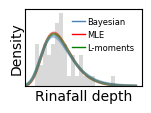

In [135]:
# ===== LEFT PANEL with SAME STYLE & SIZE AS FIRST FIGURE =====
fig, ax = plt.subplots(figsize=(1.5, 1))

# --- Histogram of annual maxima ---
ax.hist(
    data1,
    bins=20,
    density=True,
    color="black",
    alpha=0.15,
    linewidth=0,
    label="Data histogram"
)

# --- Posterior predictive mean PDF ---


# --- MLE PDF ---
ax.plot(
    x, pdf_mle,
    lw=2,
    alpha=0.5,
    color="red",
    label="MLE"
)

# --- MOM PDF ---
ax.plot(
    x, pdf_mom,
    lw=2,
    alpha=0.5,
    color="green",
    label="L-moments"
)
ax.plot(
    x, pdf_mean,
    lw=2,
    alpha=0.5,
    color="steelblue",
    label="Bayesian"
)

# ---- Axis formatting to match first plot ----
ax.set_ylabel("Density", labelpad=1)
ax.set_xlabel("Rinafall depth", labelpad=2)

ax.set_xlim(0)
ax.set_ylim(bottom=0)

ax.set_xticks([])
ax.set_yticks([])

ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

# ---- Legend (same style as first figure) ----
legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=1.0, label="Bayesian"),
    Line2D([0], [0], color="red",        linewidth=1.0, label="MLE"),
    Line2D([0], [0], color="green",      linewidth=1.0, label="L-moments"),
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    ncol=1,
    frameon=False,
    fontsize=6,
    handlelength=1.5,
    handletextpad=0.3
)

plt.tight_layout(pad=200)
plt.show()

fig.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Figure\LeftPanel_GEVPosterior.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


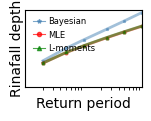

In [147]:
# ===== RIGHT PANEL with SAME STYLE & SIZE AS FIRST FIGURE =====
fig, ax = plt.subplots(figsize=(1.5, 1))

# --- Posterior mean return levels ---
ax.semilogx(
    T, q_mean*2.4,
    lw=2,
    marker="*",
    markersize=2,
    color="steelblue",
    alpha=0.5,
    label="Bayesian"
)


# --- MLE curve ---
ax.semilogx(
    T, q_mle*2.2,
    lw=2,
    marker="o",
    markersize=2,
    color="red",
    alpha=0.5,
    label="MLE"
)

# --- L-moments curve ---
ax.semilogx(
    T, q_mom*2.2,
    lw=2,
    marker="^",
    markersize=2,
    color="green",
    alpha=0.5,
    label="L-moments"
)

# ---- Axis formatting to match first figure ----
ax.set_xlabel("Return period", labelpad=2)
ax.set_ylabel("Rinafall depth", labelpad=1)

ax.set_xlim(1, 100)
ax.set_ylim(0, 100)

# no ticks
ax.set_xticks([])
ax.set_yticks([])

ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

# ---- Minimalist legend (same style as left panel) ----
legend_handles = [
    Line2D([0], [0], lw=0.8, marker="*", markersize=3, color="steelblue",  alpha=0.7, label="Bayesian"),
    Line2D([0], [0], lw=0.8, marker="o", markersize=3, color="red",        alpha=0.7, label="MLE"),
    Line2D([0], [0], lw=0.8, marker="^", markersize=3, color="green",      alpha=0.7, label="L-moments"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    ncol=1,
    frameon=False,
    fontsize=6,
    handlelength=1.5,
    handletextpad=0.3
)

plt.tight_layout(pad=200)
plt.show()

fig.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Figure\RightPanel_ReturnLevels.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


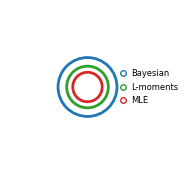

In [278]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(2, 2))
ratio=3.
# Circle sizes (your values)
sizes = [600*ratio, 300*ratio, 150*ratio]   # Bayesian, L-moments, MLE (largest → smallest)
colors = ["tab:blue", "tab:green", "tab:red"]
labels = ["Bayesian", "L-moments", "MLE"]

lw = 2

# All circles share the same center
x_center = 0.50
y_center = 0.35

for size, color in zip(sizes, colors):
    ax.scatter(
        x_center, y_center,
        s=size,
        facecolors="none",
        edgecolors=color,
        linewidths=lw
    )

# --- Legend entries ---
legend_handles = [
    Line2D([0], [0],
           marker="o",
           markersize=4,
           linestyle="None",
           markerfacecolor="none",
           markeredgecolor=clr,
           linewidth=lw,
           label=lbl)
    for lbl, clr in zip(labels, colors)
]

ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.65, 0.5),
    frameon=False,
    fontsize=6,
    handlelength=1.2,
    handletextpad=0.3
)

# Remove ticks & spines
ax.set_xticks([])
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout(pad=200)
plt.show()

fig.savefig(
    r"D:\BMM-IDF4Drainage_data_results\Figure\concentric_methods_circles_with_legend.png",
    dpi=500,
    bbox_inches="tight"
)
plt.close(fig)


# Data, MOM, MLE, Bayesian (every city)
## 24hr 

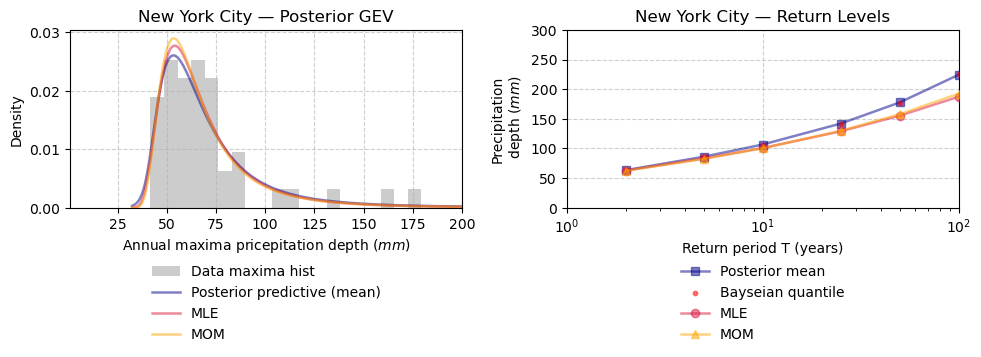

In [28]:
# --- load MLE params (CSV) ---
mle_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_24h_mle_AORC.csv')
mom_params=pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_MOM.csv')

# --- load your saved posterior samples ---
sample_1h_aorc = np.load(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_24h_AORC_Bayes.npz")
save_samples_1h = sample_1h_aorc["saved_samples_24h_AORC_Bayes"]

# pick a city index
i = 29  # <-- change this to the city you want

# map your saved arrays to parameter names (from your code’s assignment order)
xi_s    = save_samples_1h[i, 0, :]   # ξ (shape)
mu_s    = save_samples_1h[i, 1, :]   # μ (location)
sigma_s = save_samples_1h[i, 2, :]   # σ (scale)


# subset for plotting to keep it snappy
K = min(2000, xi_s.size)
rng = np.random.default_rng(12345)
idx = rng.choice(xi_s.size, size=K, replace=False)

xi_sub    = xi_s[idx]
mu_sub    = mu_s[idx]
sigma_sub = sigma_s[idx]

# --- Posterior predictive draws to set plotting range + show histogram ---
x_pred = genextreme.rvs(c=-xi_sub, loc=mu_sub, scale=sigma_sub, random_state=rng)

# x-grid covering the central mass of the predictive
x_lo, x_hi = np.nanpercentile(x_pred, [0.005, 99.5])
x = np.linspace(x_lo, x_hi, 500)

# evaluate pdf for each posterior draw on the x-grid
pdf_stack = np.empty((K, x.size))
for j in range(K):
    pdf_stack[j, :] = genextreme.pdf(x, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

# pointwise bands + summaries for the pdf
pdf_mean = np.nanmean(pdf_stack,  axis=0)       # <-- predictive mean (PDF)


# --- Bring in the city’s data (1h) to overlay histogram ---
data1 = np.array(dataframes.get(cities[i])["24h"])

# --- Compute return-levels for each posterior draw ---
T = np.array([2, 5, 10, 25, 50, 100])
p = 1 - 1 / T

q_stack = np.empty((K, T.size))
for j in range(K):
    q_stack[j, :] = genextreme.ppf(p, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

q_mean = np.nanmean(q_stack,  axis=0)           # <-- predictive mean (return levels)

# ================= MLE=================
city_name = cities[i]  # --- MLE added ---
row = mle_params.loc[mle_params['City'] == city_name].iloc[0]  # --- MLE added ---
c_mle    = float(row['shape(c)'])   
loc_mle  = float(row['loc'])        
scale_mle= float(row['scale'])   

# MLE pdf on same x-grid and MLE return levels                 # --- MLE added ---
pdf_mle = genextreme.pdf(x, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---
q_mle   = genextreme.ppf(p, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---

# ================= MOM=================
city_name = cities[i]  # --- MLE added ---
row = mom_params.loc[mle_params['City'] == city_name].iloc[0]  # --- MLE added ---
c_mom    = float(row['shape(c)'])   # SciPy's 'c' already (your CSV)  # --- MLE added ---
loc_mom  = float(row['loc'])        # --- MLE added ---
scale_mom= float(row['scale'])      # --- MLE added ---

# MLE pdf on same x-grid and MLE return levels                 # --- MLE added ---
pdf_mle = genextreme.pdf(x, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---
q_mle   = genextreme.ppf(p, c=c_mle, loc=loc_mle, scale=scale_mle)       # --- MLE added ---
# ===========================================================

# MOM pdf on same x-grid and MLE return levels                 # --- MLE added ---
pdf_mom = genextreme.pdf(x, c=c_mom, loc=loc_mom, scale=scale_mom)       # --- MLE added ---
q_mom   = genextreme.ppf(p, c=c_mom, loc=loc_mom, scale=scale_mom)       # --- MLE added ---
# ===========================================================



# --- Combined figure: two panels in one row ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.3)

# ===== Left panel: Posterior GEV PDF =====
ax = axes[0]
ax.hist(data1, bins=20, density=True,color='black', alpha=0.2, label="Data maxima hist")


# credible band and summary curves
ax.plot(x, pdf_mean, lw=1.8, color='darkblue', label="Posterior predictive (mean)",alpha=0.5,   zorder=3)
# --- MLE overlay line ---
ax.plot(x, pdf_mle, lw=1.8, linestyle='-', color='crimson', label="MLE",alpha=0.5, zorder=4)  # --- MLE added ---
# --- MOM overlay line ---
ax.plot(x, pdf_mom, lw=1.8, linestyle='-', color='orange', label="MOM",alpha=0.5, zorder=5)  # --- MLE added ---


ax.set_xlabel(f"Annual maxima pricepitation depth ($mm$)")
ax.set_ylabel("Density")
ax.set_title(f"{cities[i]} — Posterior GEV")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(0, )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    frameon=False,
)
ax.set_xlim(1, 200)

# ===== Right panel: Return-Level plot =====

df = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_24h_AORC_Bayes.csv')

# columns in the CSV are strings like "50","80",...
perc_cols = ["50", "80", "90", "96", "98", "99"]
T_perc    = np.array([2, 5, 10, 25, 50, 100], dtype=float)  # mapping: T = 1/(1-p)

# pick the row for the current city (using your existing `cities[i]`)
row = df.loc[df["City"] == cities[i]].iloc[0]
y_perc = row[perc_cols].to_numpy(dtype=float)


ax = axes[1]


# credible band + summary curves
ax.semilogx(T, q_mean, lw=1.8, marker="s", color='darkblue', label="Posterior mean",alpha=0.5,   zorder=3)
ax.scatter(T_perc, y_perc, marker='.', linestyle='-', lw=1.2,color='red',label="Bayseian quantile", alpha=0.5,zorder=4)
ax.semilogx(T, q_mle, lw=1.8, linestyle='-', marker='o', color='crimson', label="MLE",alpha=0.5, zorder=4)  #
ax.semilogx(T, q_mom, lw=1.8, linestyle='-', marker='^', color='orange', label="MOM",alpha=0.5, zorder=5)  #


ax.set_xlabel("Return period T (years)")
ax.set_xlim(1, 100)
ax.set_ylim(0, 300)
ax.set_ylabel(f"Precipitation\n depth ($mm$)")
ax.set_title(f"{cities[i]} — Return Levels")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    frameon=False,
)

plt.tight_layout()
plt.savefig(r'D:\BMM-IDF4Drainage_data_results\Figure\New York City_24hr_return_level.png',dpi=300, bbox_inches="tight")
plt.show()


# Show the all cities and all methods

In [48]:
plt.rcParams.update({
    "font.size": 12,          # general font size
    "axes.titlesize": 14,     # title font
    "axes.labelsize": 14,     # x/y label font
    "xtick.labelsize": 14,    # x-tick font
    "ytick.labelsize": 12,    # y-tick font
    "legend.fontsize": 10,    # legend text
    "legend.title_fontsize": 12
})

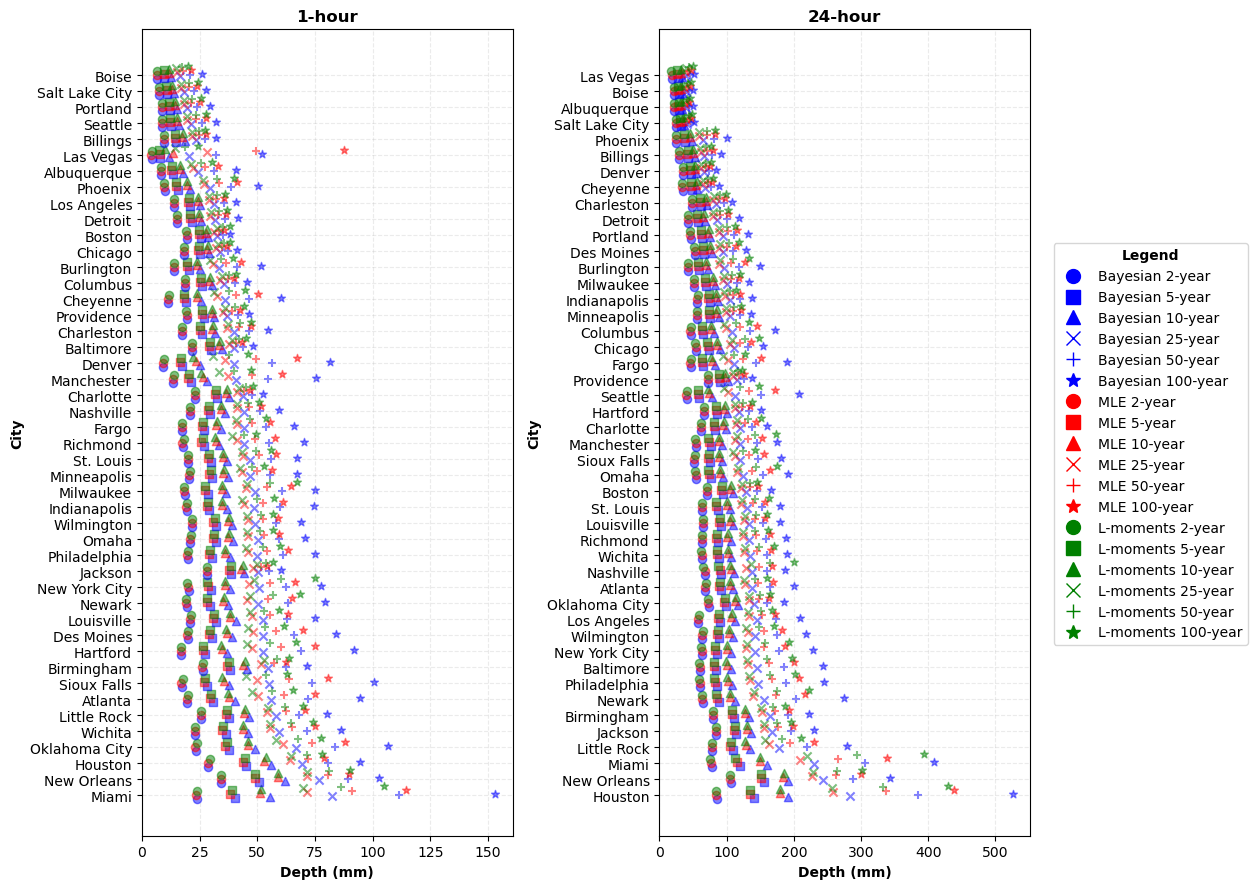

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Spacing controls (IMPORTANT)
# --------------------------
row_spacing = 6.0         # spacing between cities
rp_jitter   = 0.40        # spacing between return periods within each method
method_spacing = 1.50     # spacing between Bayesian / MLE / MOM

# --------------------------
# File paths
# --------------------------
# Bayesian
b_1h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_Bayesian.csv'
b_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_Bayes.csv'

# MLE
mle_1h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_mle_AORC.csv'
mle_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_mle_AORC.csv'

# MOM
mom_1h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv'
mom_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_MOM.csv'

# --------------------------
# Load data
# --------------------------
df_b_1h   = pd.read_csv(b_1h)
df_b_24h  = pd.read_csv(b_24h)
df_mle_1h = pd.read_csv(mle_1h)
df_mle_24h= pd.read_csv(mle_24h)
df_mom_1h = pd.read_csv(mom_1h)
df_mom_24h= pd.read_csv(mom_24h)

# Return periods and markers
rp_list  = [2, 5, 10, 25, 50, 100]
rp_cols  = list(map(str, rp_list))
markers  = ["o", "s", "^", "x", "+", "*"]

# Ensure numeric
for df in [df_b_1h, df_b_24h, df_mle_1h, df_mle_24h, df_mom_1h, df_mom_24h]:
    for c in rp_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# --------------------------
# Method colors + vertical offsets
# --------------------------
methods = [
    ("Bayesian", "blue",  0 * method_spacing),
    ("MLE",      "red",   1 * method_spacing),
    ("MOM",      "green", 2 * method_spacing),
]

offset_values  = [m[2] for m in methods]
center_offset  = sum(offset_values) / len(offset_values)

# --------------------------
# Create figure
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(10.5, 9))

# --------------------------
# Plot each dataset: 1h and 24h
# --------------------------
for subplot_index, (df_b, df_mle, df_mom, title) in enumerate([
    (df_b_1h,  df_mle_1h,  df_mom_1h,  "1-hour"),
    (df_b_24h, df_mle_24h, df_mom_24h, "24-hour")
]):

    # Sort cities by total Bayesian depth
    city_depth_sums = df_b[rp_cols].sum(axis=1)
    sorted_idx = city_depth_sums.sort_values(ascending=False).index
    sorted_cities = df_b.loc[sorted_idx, "City"].tolist()

    # Plot each city
    for i, city in enumerate(sorted_cities):

        depths_map = {
            "Bayesian": df_b.loc[df_b["City"] == city, rp_cols].values[0],
            "MLE":      df_mle.loc[df_mle["City"] == city, rp_cols].values[0],
            "MOM":      df_mom.loc[df_mom["City"] == city, rp_cols].values[0],
        }

        for method_name, color, method_offset in methods:

            for j, rp in enumerate(rp_list):

                depth_val = depths_map[method_name][j]

                # FULLY CORRECTED vertical coordinate
                y_val = (
                    i * row_spacing          # city-level spacing
                    + j * rp_jitter          # RP separation
                    + method_offset          # method separation
                )

                axes[subplot_index].scatter(
                    depth_val, y_val,
                    marker=markers[j],
                    color=color,
                    alpha=0.5,
                    s=35
                )

    # --------------------------
    # Labels and formatting
    # --------------------------
    axes[subplot_index].set_xlabel("Depth (mm)",fontweight='bold')
    axes[subplot_index].set_ylabel("City",fontweight='bold')
    axes[subplot_index].set_title(title,fontweight='bold')
    axes[subplot_index].grid(True, linestyle="--", alpha=0.25)
    axes[subplot_index].set_xlim(left=0)

    # --------------------------
    # Legend
    # --------------------------
    handles = []
    labels  = []
    for method_name, color, _ in methods:
        legend_name = "L-moments" if method_name == "MOM" else method_name
        for j, rp in enumerate(rp_list):
            h = plt.Line2D([], [], linestyle="", marker=markers[j],
                        color=color, markersize=10)
            handles.append(h)
            labels.append(f"{legend_name} {rp}-year")

    axes[subplot_index].legend(handles, labels, title="Legend")

    # --------------------------
    # Correct y-ticks for city labels
    # --------------------------
    yticks = [i * row_spacing + center_offset for i in range(len(sorted_cities))]
    axes[subplot_index].set_yticks(yticks)
    axes[subplot_index].set_yticklabels(sorted_cities)

# --- REMOVE subplot legends ---
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

# --- CREATE one combined legend at bottom center ---
#fig.legend(
#    handles=handles,
#    labels=labels,
#    title="Legend",
#    title_fontproperties={"weight": "bold"}, 
#    loc="lower center",
#    ncol=4,           # 6 columns × 3 rows (18 items total)
#    bbox_to_anchor=(0.5, 0.98),  # move slightly below the figure
#    frameon=True,
#)
# --- CREATE one combined legend at bottom center ---
fig.legend(
    handles=handles,
    labels=labels,
    title="Legend",
    title_fontproperties={"weight": "bold"}, 
    loc="center right",
    ncol=1,           # 6 columns × 3 rows (18 items total)
    bbox_to_anchor=(1.2, 0.5),  # move slightly below the figure
    frameon=True,
)

plt.tight_layout()
plt.savefig(
    r'D:\BMM-IDF4Drainage_data_results\Figure\extreme_return_levels_all_cities_methods_AORC.png',
    dpi=300, bbox_inches="tight"
)
plt.show()


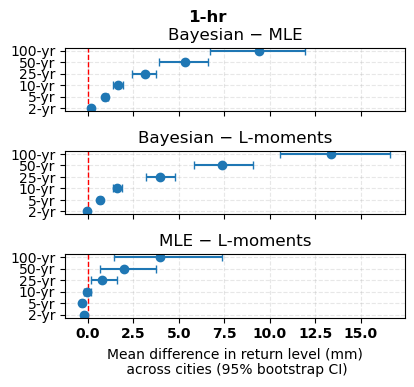

font.weight: normal
axes.labelweight: normal
axes.titleweight: normal


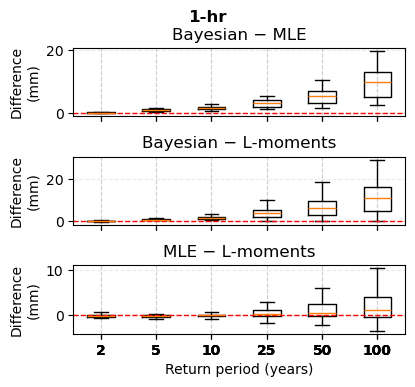


1-hour RESULTS (cities as replicates)
Significant if: (FDR-adjusted Wilcoxon q < 0.05) AND (95% CI excludes 0)
duration             contrast  rp  n_cities  mean_diff    ci_low   ci_high  q_wilcoxon_fdr  ci_excludes_0  sig_qw_0p05
  1-hour Bayesian − L-moments   2        46  -0.012052 -0.085019  0.065987    7.973746e-01          False        False
  1-hour Bayesian − L-moments   5        46   0.674288  0.586054  0.770179    4.516941e-09           True         True
  1-hour Bayesian − L-moments  10        46   1.617094  1.382988  1.864792    4.516941e-09           True         True
  1-hour Bayesian − L-moments  25        46   3.954640  3.200294  4.776764    4.516941e-09           True         True
  1-hour Bayesian − L-moments  50        46   7.381110  5.841751  9.096328    4.516941e-09           True         True
  1-hour Bayesian − L-moments 100        46  13.388606 10.541954 16.584493    4.516941e-09           True         True
  1-hour       Bayesian − MLE   2        46   0.184783 

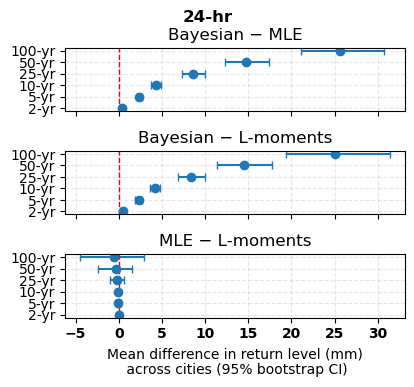

font.weight: normal
axes.labelweight: normal
axes.titleweight: normal


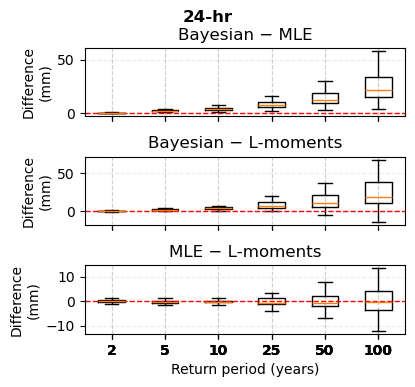


24-hour RESULTS (cities as replicates)
Significant if: (FDR-adjusted Wilcoxon q < 0.05) AND (95% CI excludes 0)
duration             contrast  rp  n_cities  mean_diff    ci_low   ci_high  q_wilcoxon_fdr  ci_excludes_0  sig_qw_0p05
 24-hour Bayesian − L-moments   2        46   0.484501  0.268100  0.726836    1.403829e-04           True         True
 24-hour Bayesian − L-moments   5        46   2.284273  1.899980  2.721930    7.045901e-09           True         True
 24-hour Bayesian − L-moments  10        46   4.175191  3.565409  4.822485    7.045901e-09           True         True
 24-hour Bayesian − L-moments  25        46   8.394075  6.893333 10.040516    7.045901e-09           True         True
 24-hour Bayesian − L-moments  50        46  14.449944 11.405288 17.692786    9.549658e-09           True         True
 24-hour Bayesian − L-moments 100        46  25.098635 19.411160 31.367168    1.057016e-08           True         True
 24-hour       Bayesian − MLE   2        46   0.421739

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# USER SETTINGS (edit these paths)
# ============================================================
# Bayesian
b_1h   = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_Bayesian.csv'
b_24h  = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_Bayes.csv'

# MLE
mle_1h  = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_mle_AORC.csv'
mle_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_mle_AORC.csv'

# L-moments (MOM in your naming)
mom_1h  = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv'
mom_24h = r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_MOM.csv'

# Output folder
out_dir = r'D:\BMM-IDF4Drainage_data_results\Figure\method_comparisons'
os.makedirs(out_dir, exist_ok=True)

# Return periods (must match your column names: "2","5","10","25","50","100")
rp_list = [2, 5, 10, 25, 50, 100]
rp_cols = list(map(str, rp_list))

# Bootstrap settings
N_BOOT = 10000
CI_LEVEL = 0.95
RANDOM_SEED = 123
# ============================================================
# DISPLAY LABELS (robust contrast naming)
# ============================================================
METHOD_DISPLAY = {
    "Bayesian": "Bayesian",
    "MLE": "MLE",
    "LMom": "L-moments",   # or "L-mom"
}
MINUS = "\N{MINUS SIGN}"   # "−" (U+2212)

# ============================================================
# HELPERS
# ============================================================
def to_numeric_rps(df, rp_cols):
    df = df.copy()
    for c in rp_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def bootstrap_ci(x, func=np.mean, n_boot=10000, ci=0.95, seed=12345):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True)
    vals = func(boots, axis=1)
    alpha = 1 - ci
    lo = np.quantile(vals, alpha/2)
    hi = np.quantile(vals, 1 - alpha/2)
    return lo, hi

def fdr_bh(pvals):
    """Benjamini-Hochberg FDR; returns q-values in original order."""
    pvals = np.asarray(pvals, dtype=float)
    n = pvals.size
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(1, n+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return out

def paired_tests(diff):
    """diff = methodA - methodB across cities."""
    diff = pd.Series(diff).dropna()
    n = diff.size
    if n < 2:
        return np.nan, np.nan, n

    # Paired t-test on differences vs 0
    t_res = stats.ttest_1samp(diff.values, popmean=0.0, nan_policy="omit")
    p_t = float(t_res.pvalue) if np.isfinite(t_res.pvalue) else np.nan

    # Wilcoxon signed-rank (requires non-all-zero diffs)
    if np.allclose(diff.values, 0.0, atol=0, rtol=0):
        p_w = 1.0
    else:
        try:
            w_res = stats.wilcoxon(diff.values, zero_method="wilcox", alternative="two-sided", mode="auto")
            p_w = float(w_res.pvalue)
        except Exception:
            p_w = np.nan

    return p_t, p_w, n

def forest_plot(summary_df, duration_label, outpath):
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert "1-hour" -> "1-hr", "24-hour" -> "24-hr"
    duration_short = (
        str(duration_label)
        .replace("-hour", "-hr")
        .replace(" hour", " hr")
        .replace("hours", "hr")
    )

    contrasts = summary_df["contrast"].unique().tolist()
    fig, axes = plt.subplots(
        len(contrasts), 1,
        figsize=(8.5 * 0.5, 2.6 * len(contrasts) * 0.5),
        sharex=True
    )
    if len(contrasts) == 1:
        axes = [axes]

    # One title for the whole figure
    fig.suptitle(f"{duration_short}", fontweight="bold")

    for ax, con in zip(axes, contrasts):
        sub = summary_df[summary_df["contrast"] == con].sort_values("rp").reset_index(drop=True)

        y = np.arange(len(sub))
        mean = sub["mean_diff"].values
        lo   = sub["ci_low"].values
        hi   = sub["ci_high"].values
        xerr = np.vstack([mean - lo, hi - mean])

        ax.errorbar(mean, y, xerr=xerr, fmt="o", capsize=3)
        ax.axvline(0, linestyle="--", linewidth=1,color="red")
        ax.set_yticks(y)
        ax.set_yticklabels([f"{int(r)}-yr" for r in sub["rp"].values])

        # Subplot title: just the methods/contrast
        ax.set_title(con)

        ax.grid(True, linestyle="--", alpha=0.3)

    axes[-1].set_xlabel("Mean difference in return level (mm)\n across cities (95% bootstrap CI)")
    for lbl in axes[-1].get_xticklabels():
        lbl.set_fontweight("bold")
    # Leave room for the suptitle
    plt.tight_layout(rect=[0, 0, 1, 1.05])

    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def boxplot_diffs(long_df, duration_label, outpath,ylim=None):
    # Convert "1-hour" -> "1-hr", "24-hour" -> "24-hr"
    duration_short = (
        str(duration_label)
        .replace("-hour", "-hr")
        .replace(" hour", " hr")
        .replace("hours", "hr")
    )

    contrasts = long_df["contrast"].unique().tolist()

    # ---- global y-limits across ALL contrasts & return periods (for this duration) ----
    y = pd.to_numeric(long_df["diff_mm"], errors="coerce").dropna().values
    if y.size > 0:
        ymin = float(np.quantile(y, 0.0005))   # 20th percentile
        ymax = float(np.quantile(y, 0.9995))   # 80th percentile

        # optional small padding so boxes don't touch the frame
        pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
        ymin -= pad
        ymax += pad
    else:
        ymin, ymax = -1.0, 1.0

    fig, axes = plt.subplots(
        len(contrasts), 1,
        figsize=(8.5 * 0.5, 2.6 * len(contrasts) * 0.5),
        sharex=True,
        sharey=True   # <-- key
    )
    if len(contrasts) == 1:
        axes = [axes]

    fig.suptitle(f"{duration_short}", fontweight="bold")

    for ax, con in zip(axes, contrasts):
        sub = long_df[long_df["contrast"] == con].copy()

        data = [sub[sub["rp"] == rp]["diff_mm"].dropna().values for rp in rp_list]
        ax.boxplot(data, labels=[str(rp) for rp in rp_list], showfliers=False)

        ax.axhline(0, linestyle="--", linewidth=1, color="red")
        ax.set_title(con)
        ax.set_ylabel("Difference\n(mm)")
        ax.grid(True, linestyle="--", alpha=0.25)

        if ylim is not None:
            ax.set_ylim(ylim[0], ylim[1])  

    axes[-1].set_xlabel("Return period (years)")
    for lbl in axes[-1].get_xticklabels():
        lbl.set_fontweight("bold")

    plt.tight_layout(rect=[0, 0, 1, 1.05])
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
# ============================================================
# CORE ANALYSIS
# ============================================================
def analyze_duration(df_b, df_mle, df_mom, duration_label):
    # Align on City (inner join)
    df_b   = to_numeric_rps(df_b, rp_cols)[["City"] + rp_cols].rename(columns={c: f"Bayesian_{c}" for c in rp_cols})
    df_mle = to_numeric_rps(df_mle, rp_cols)[["City"] + rp_cols].rename(columns={c: f"MLE_{c}" for c in rp_cols})
    df_mom = to_numeric_rps(df_mom, rp_cols)[["City"] + rp_cols].rename(columns={c: f"LMom_{c}" for c in rp_cols})

    merged = df_b.merge(df_mle, on="City", how="inner").merge(df_mom, on="City", how="inner")

    contrasts = [
        ("Bayesian", "MLE"),
        ("Bayesian", "LMom"),
        ("MLE",      "LMom"),
    ]

    summary_rows = []
    long_rows = []

    for  a, b in contrasts:
        con_name = f"{METHOD_DISPLAY[a]} {MINUS} {METHOD_DISPLAY[b]}"
        pvals_t = []
        pvals_w = []
        idx_rows = []

        for rp, rp_col in zip(rp_list, rp_cols):
            a_col = f"{a}_{rp_col}"
            b_col = f"{b}_{rp_col}"
            diff = merged[a_col] - merged[b_col]

            # Stats across cities
            mean_diff = float(np.nanmean(diff))
            med_diff  = float(np.nanmedian(diff))
            mae       = float(np.nanmean(np.abs(diff)))
            rmse      = float(np.sqrt(np.nanmean(diff**2)))

            # Percent difference relative to the "b" method (avoid division by ~0)
            denom = merged[b_col].replace(0, np.nan)
            pct = 100.0 * (diff / denom)
            mean_pct = float(np.nanmean(pct))

            # Bootstrap CI for mean diff
            ci_lo, ci_hi = bootstrap_ci(diff.values, func=np.mean, n_boot=N_BOOT, ci=CI_LEVEL, seed=RANDOM_SEED + rp)

            # Significance tests (paired across cities)
            p_t, p_w, n = paired_tests(diff)

            row = {
                "duration": duration_label,
                "contrast": con_name,
                "rp": rp,
                "n_cities": n,
                "mean_diff_mm": mean_diff,
                "ci_low_mm": ci_lo,
                "ci_high_mm": ci_hi,
                "median_diff_mm": med_diff,
                "mae_mm": mae,
                "rmse_mm": rmse,
                "mean_pct_diff_%": mean_pct,
                "p_ttest": p_t,
                "p_wilcoxon": p_w,
            }
            summary_rows.append(row)

            # For later FDR within each contrast
            pvals_t.append(p_t)
            pvals_w.append(p_w)
            idx_rows.append(len(summary_rows) - 1)

            # Long-form for boxplots
            for val in diff.dropna().values:
                long_rows.append({
                    "duration": duration_label,
                    "contrast": con_name,
                    "rp": rp,
                    "diff_mm": float(val),
                })

        # FDR adjust across RPs for this contrast
        pvals_t_arr = np.array(pvals_t, dtype=float)
        pvals_w_arr = np.array(pvals_w, dtype=float)

        # If any NaNs, keep them as NaN
        q_t = np.full_like(pvals_t_arr, np.nan, dtype=float)
        q_w = np.full_like(pvals_w_arr, np.nan, dtype=float)

        mask_t = np.isfinite(pvals_t_arr)
        mask_w = np.isfinite(pvals_w_arr)

        if mask_t.sum() > 0:
            q_t[mask_t] = fdr_bh(pvals_t_arr[mask_t])
        if mask_w.sum() > 0:
            q_w[mask_w] = fdr_bh(pvals_w_arr[mask_w])

        # write back
        for k, row_idx in enumerate(idx_rows):
            summary_rows[row_idx]["q_ttest_fdr"] = float(q_t[k]) if np.isfinite(q_t[k]) else np.nan
            summary_rows[row_idx]["q_wilcoxon_fdr"] = float(q_w[k]) if np.isfinite(q_w[k]) else np.nan

    summary_df = pd.DataFrame(summary_rows).rename(columns={
        "mean_diff_mm": "mean_diff",
        "ci_low_mm": "ci_low",
        "ci_high_mm": "ci_high",
        "median_diff_mm": "median_diff",
        "mae_mm": "mae",
        "rmse_mm": "rmse",
        "mean_pct_diff_%": "mean_pct_diff_pct",
    })
    long_df = pd.DataFrame(long_rows)

    # Save tables
    summary_csv = os.path.join(out_dir, f"method_diff_summary_{duration_label.replace('-', '').replace(' ', '_')}.csv")
    summary_df.to_csv(summary_csv, index=False)

    # Plots
    forest_path = os.path.join(out_dir, f"forest_mean_diffs_{duration_label}.png")
    forest_plot(summary_df, duration_label, forest_path)

    box_path = os.path.join(out_dir, f"boxplot_city_diffs_{duration_label}.png")
    if duration_label == "1-hour":
        boxplot_diffs(long_df, duration_label, box_path, ylim=(-10, 40))
    elif duration_label == "24-hour":
        boxplot_diffs(long_df, duration_label, box_path, ylim=(-20, 75))
    else:
        boxplot_diffs(long_df, duration_label, box_path)

    # Also print a compact “significance” view
    # (Here: declare “significant” if FDR-adjusted Wilcoxon q < 0.05 AND CI excludes 0)
    sig = summary_df.copy()
    sig["ci_excludes_0"] = ~((sig["ci_low"] <= 0) & (sig["ci_high"] >= 0))
    sig["sig_qw_0p05"] = sig["q_wilcoxon_fdr"] < 0.05
    sig_view = sig[[
        "duration","contrast","rp","n_cities",
        "mean_diff","ci_low","ci_high",
        "q_wilcoxon_fdr","ci_excludes_0","sig_qw_0p05"
    ]].sort_values(["contrast","rp"])

    print("\n============================================================")
    print(f"{duration_label} RESULTS (cities as replicates)")
    print("Significant if: (FDR-adjusted Wilcoxon q < 0.05) AND (95% CI excludes 0)")
    print(sig_view.to_string(index=False))
    print(f"\nSaved:\n  {summary_csv}\n  {forest_path}\n  {box_path}")
    print("============================================================\n")

    return summary_df, long_df

# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":
    df_b_1h   = pd.read_csv(b_1h)
    df_b_24h  = pd.read_csv(b_24h)
    df_mle_1h = pd.read_csv(mle_1h)
    df_mle_24h= pd.read_csv(mle_24h)
    df_mom_1h = pd.read_csv(mom_1h)
    df_mom_24h= pd.read_csv(mom_24h)

    # 1-hour
    analyze_duration(df_b_1h, df_mle_1h, df_mom_1h, "1-hour")

    # 24-hour
    analyze_duration(df_b_24h, df_mle_24h, df_mom_24h, "24-hour")


# Pipe size

## 1hr VS 24hr historical

In [ ]:

df_1h=pd.read_csv("D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_1_hr.csv")
df_24h=pd.read_csv("D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv")
def plot_two_cols_overlay_split(df_1h, df_24h, 
                                n_cols=2, pair_gap=0.06, row_step=1,
                                fig_width=8, row_scale=0.45,
                                left_pad=0.005, right_pad=0.012):
    """
    n_cols     : number of city columns (2 = split list into two columns)
    pair_gap   : horizontal distance between the 1-hr and 24-hr points (smaller = closer)
    row_step   : vertical spacing between consecutive cities within a column
    fig_width  : overall width of the figure in inches
    row_scale  : controls vertical density (smaller = more compact)
    """
    cols = ['City', 'Bayesian', 'MLE', 'MOM']
    df1  = df_1h[cols].copy()
    df24 = df_24h[cols].copy()

    # Align by city
    cities = sorted(set(df1['City']).union(df24['City']))
    df1  = df1.set_index('City').reindex(cities)
    df24 = df24.set_index('City').reindex(cities)
    n_cities = len(cities)

    # Split into columns
    n_rows = int(np.ceil(n_cities / n_cols))
    city_cols = [cities[i*n_rows:(i+1)*n_rows] for i in range(n_cols)]

    # Style
    methods = ['MOM', 'MLE', 'Bayesian']
    colors  = {'Bayesian':'tab:blue', 'MLE':'tab:red', 'MOM':'tab:green'}
    linestyles = {'Bayesian': '-', 'MLE': '--', 'MOM': ':'}


    k = 0.0115
    def size_from_mm(mm): return ((k * np.asarray(mm))**3)*(np.pi)/4

    x_center = 0.5
    x_pos = {'1h': x_center - pair_gap/2.0,
             '24h': x_center + pair_gap/2.0}

    # Figure setup
    fig_h = n_rows * row_scale
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, fig_h), sharex=True)
    if n_cols == 1:
        axes = [axes]

    def plot_column(ax, city_list):
        y = np.arange(len(city_list)) * row_step

        def plot_df(df_col, label):
            x = np.full_like(y, x_pos[label], dtype=float)
            for i, city in enumerate(city_list):
                vals = {m: df_col.loc[city, m] for m in methods} if city in df_col.index else {}
                vals = {m: v for m, v in vals.items() if pd.notna(v)}
                for m, v in sorted(vals.items(), key=lambda kv: kv[1], reverse=True):
                    ax.scatter(x[i], y[i],
                               s=size_from_mm(v),
                               facecolors='none',
                               edgecolors=colors[m],
                               linestyles=linestyles[m],
                               linewidths=2,
                               alpha=0.3)
        plot_df(df1, '1h')
        plot_df(df24, '24h')

        # tighten layout and limits
        ax.set_yticks(y)
        ax.set_yticklabels(city_list)
        ax.invert_yaxis()
        ax.set_xticks([x_pos['1h'], x_pos['24h']])
        ax.set_xticklabels(['1-hour', '24-hour'])
        ax.tick_params(axis='both', length=0, pad=1)
        ax.tick_params(axis='y', length=0, pad=-1)
        ax.set_facecolor('none')
        for sp in ax.spines.values(): sp.set_visible(False)

        # tighter horizontal limits (reduce inner white space)
        ax.set_xlim(x_pos['1h'] - left_pad,           # ← was (0.45, 0.55)
                    x_pos['24h'] + right_pad)

    for ax, clist in zip(axes, city_cols):
        plot_column(ax, clist)

    # Legends
    axL = axes[-1]
    legend_sizes_mm = [450, 600, 750, 900, 1050,1200]
    handles_size = [
        plt.scatter([], [], s=size_from_mm(mm),
                    facecolors='none', edgecolors='k', linewidths=1.0)
        for mm in legend_sizes_mm
    ]
    labels_size = [f"{mm}" for mm in legend_sizes_mm]

    size_leg = axL.legend(
        handles=handles_size,
        labels=labels_size,
        title=f'Pipe size ($mm$) ',
        title_fontproperties={'weight': 'bold'},  # bold title
        loc='center left',
        bbox_to_anchor=(0.6, 0.4),
        frameon=False,
        scatterpoints=1,
        handleheight=1.4,     # vertical centering
        handletextpad=1.5,    # spacing between circle and text
        labelspacing=4,     # vertical spacing between entries
        handler_map={PathCollection: HandlerPathCollection(update_func=None)}
    )
    axL.add_artist(size_leg)
    name_map = {'MOM': 'L-moments', 'MLE': 'MLE', 'Bayesian': 'Bayesian'}

    method_handles = [
        Line2D([0], [0],
            linestyle=linestyles[m],
            markerfacecolor='none',
            color=colors[m],
            markersize=8,
            linewidth=2,
            label=name_map[m])
        for m in methods
            ]

    axL.legend(handles=method_handles, title='Method',title_fontproperties={'weight': 'bold'},
            loc='center left', bbox_to_anchor=(0.6, 0.75),
            frameon=False, handlelength=1.5)

    plt.savefig(r'D:\BMM-IDF4Drainage_data_results\Figure\pipesizes_all_cities_methods_AORC.png',dpi=300, bbox_inches="tight")
    plt.show()
plot_two_cols_overlay_split(df_1h, df_24h,
    n_cols=3, pair_gap=0.0075, row_step=.01,
    fig_width=8, row_scale=0.75)

### Different diameters

In [ ]:
df_1h = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_1_hr.csv")
df_24h = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv")

def plot_two_cols_overlay_split(df_1h, df_24h, 
                                n_cols=2, pair_gap=0.06, row_step=1,
                                fig_width=8, row_scale=0.45,
                                left_pad=0.005, right_pad=0.012):
    """
    Plots only cities where, in the 1-hour triplet or 24-hour triplet,
    at least one method value differs from the other two.
    """

    # -------------------------------
    # 1) FILTERING STEP
    # -------------------------------
    cols = ['MOM', 'MLE', 'Bayesian']

    df1  = df_1h.set_index('City')
    df24 = df_24h.set_index('City')

    selected_cities = []
    for city in df1.index.union(df24.index):
        row1 = df1.loc[city, cols] if city in df1.index else None
        row24 = df24.loc[city, cols] if city in df24.index else None

        diff1  = row1.nunique() > 1 if row1 is not None else False
        diff24 = row24.nunique() > 1 if row24 is not None else False

        if diff1 or diff24:
            selected_cities.append(city)

    # keep only filtered cities
    df_1h = df_1h[df_1h["City"].isin(selected_cities)]
    df_24h = df_24h[df_24h["City"].isin(selected_cities)]

    # -------------------------------
    # 2) ORIGINAL PLOTTING CODE
    # -------------------------------
    cols = ['City', 'Bayesian', 'MLE', 'MOM']
    df1  = df_1h[cols].copy()
    df24 = df_24h[cols].copy()

    cities = sorted(set(df1['City']).union(df24['City']))
    df1  = df1.set_index('City').reindex(cities)
    df24 = df24.set_index('City').reindex(cities)
    n_cities = len(cities)

    n_rows = int(np.ceil(n_cities / n_cols))
    city_cols = [cities[i*n_rows:(i+1)*n_rows] for i in range(n_cols)]

    methods = ['MOM', 'MLE', 'Bayesian']
    colors  = {'Bayesian':'tab:blue', 'MLE':'tab:red', 'MOM':'tab:green'}
    linestyles = {'Bayesian': '-', 'MLE': '--', 'MOM': ':'}

    k = 0.0115
    def size_from_mm(mm):
        return ((k * np.asarray(mm))**3)*(np.pi)/4

    x_center = 0.5
    x_pos = {'1h': x_center - pair_gap/2.0,
             '24h': x_center + pair_gap/2.0}

    fig_h = n_rows * row_scale
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, fig_h), sharex=True)
    if n_cols == 1:
        axes = [axes]

    def plot_column(ax, city_list):
        y = np.arange(len(city_list)) * row_step

        def plot_df(df_col, label):
            x = np.full_like(y, x_pos[label], dtype=float)
            for i, city in enumerate(city_list):
                vals = {m: df_col.loc[city, m] for m in methods} if city in df_col.index else {}
                vals = {m: v for m, v in vals.items() if pd.notna(v)}
                for m, v in sorted(vals.items(), key=lambda kv: kv[1], reverse=True):
                    ax.scatter(x[i], y[i],
                               s=size_from_mm(v),
                               facecolors='none',
                               edgecolors=colors[m],
                               linestyles=linestyles[m],
                               linewidths=2,
                               alpha=0.3)

        plot_df(df1, '1h')
        plot_df(df24, '24h')

        ax.set_yticks(y)
        ax.set_yticklabels(city_list)
        ax.invert_yaxis()
        ax.set_xticks([x_pos['1h'], x_pos['24h']])
        ax.set_xticklabels(['1-hour', '24-hour'])
        ax.tick_params(axis='both', length=0, pad=10)
        ax.set_facecolor('none')
        for sp in ax.spines.values():
            sp.set_visible(False)

        ax.set_xlim(x_pos['1h'] - left_pad, x_pos['24h'] + right_pad)

    for ax, clist in zip(axes, city_cols):
        plot_column(ax, clist)

    axL = axes[-1]
    legend_sizes_mm = [450, 600, 750, 900, 1050,1200]
    handles_size = [
        plt.scatter([], [], s=size_from_mm(mm),
                    facecolors='none', edgecolors='k', linewidths=1.0)
        for mm in legend_sizes_mm
    ]
    labels_size = [f"{mm}" for mm in legend_sizes_mm]

    size_leg = axL.legend(
        handles=handles_size,
        labels=labels_size,
        title=f'Pipe size ($mm$)',
        title_fontproperties={'weight': 'bold'},
        loc='center left',
        bbox_to_anchor=(0.65, 0.4),
        frameon=False,
        scatterpoints=1,
        handleheight=0.5,
        handletextpad=1.5,
        labelspacing=4,
        handler_map={PathCollection: HandlerPathCollection(update_func=None)}
    )

    title = size_leg.get_title()
    title.set_va("bottom")
    title.set_position((0, -50))

    axL.add_artist(size_leg)

    name_map = {'MOM': 'L-moments', 'MLE': 'MLE', 'Bayesian': 'Bayesian'}

    method_handles = [
        Line2D([0], [0],
               linestyle=linestyles[m],
               markerfacecolor='none',
               color=colors[m],
               markersize=8,
               linewidth=2,
               label=name_map[m])
        for m in methods
    ]

    axL.legend(handles=method_handles, title='Method',
               title_fontproperties={'weight': 'bold'},
               loc='center left', bbox_to_anchor=(0.6, 0.92),
               frameon=False, handlelength=1.5)

    plt.savefig(r'D:\BMM-IDF4Drainage_data_results\Figure\pipesizes_filtered_cities_AORC.png',
                dpi=300, bbox_inches="tight")
    plt.show()


# ---- RUN ----
plot_two_cols_overlay_split(df_1h, df_24h,
                            n_cols=3, pair_gap=0.0075, row_step=.01,
                            fig_width=8.5, row_scale=1)


## Projeccted vs historical

In [ ]:

df_24h_cmip6=pd.read_csv("D:\BMM-IDF4Drainage_data_results\Pipe size\CMIP6_24_hr.csv")
df_24h=pd.read_csv("D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv")
def plot_two_cols_overlay_split(df_24h_cmip6, df_24h, 
                                n_cols=2, pair_gap=0.06, row_step=1,
                                fig_width=8, row_scale=0.45,
                                left_pad=0.005, right_pad=0.012):
    """
    n_cols     : number of city columns (2 = split list into two columns)
    pair_gap   : horizontal distance between the 1-hr and 24-hr points (smaller = closer)
    row_step   : vertical spacing between consecutive cities within a column
    fig_width  : overall width of the figure in inches
    row_scale  : controls vertical density (smaller = more compact)
    """
    cols = ['City', 'Bayesian', 'MLE', 'MOM']
    df1  = df_24h_cmip6[cols].copy()
    df24 = df_24h[cols].copy()

    # Align by city
    cities = sorted(set(df1['City']).union(df24['City']))
    df1  = df1.set_index('City').reindex(cities)
    df24 = df24.set_index('City').reindex(cities)
    n_cities = len(cities)

    # Split into columns
    n_rows = int(np.ceil(n_cities / n_cols))
    city_cols = [cities[i*n_rows:(i+1)*n_rows] for i in range(n_cols)]

    # Style
    methods = ['MOM', 'MLE', 'Bayesian']
    colors  = {'Bayesian':'tab:blue', 'MLE':'tab:red', 'MOM':'tab:green'}
    linestyles = {'Bayesian': '-', 'MLE': '--', 'MOM': ':'}


    k = 0.0115
    def size_from_mm(mm):
        return ((k * np.asarray(mm))**3)*(np.pi)/4

    x_center = 0.5
    x_pos = {'1h': x_center - pair_gap/2.0,
             '24h': x_center + pair_gap/2.0}

    # Figure setup
    fig_h = n_rows * row_scale
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, fig_h), sharex=True)
    if n_cols == 1:
        axes = [axes]

    def plot_column(ax, city_list):
        y = np.arange(len(city_list)) * row_step

        def plot_df(df_col, label):
            x = np.full_like(y, x_pos[label], dtype=float)
            for i, city in enumerate(city_list):
                vals = {m: df_col.loc[city, m] for m in methods} if city in df_col.index else {}
                vals = {m: v for m, v in vals.items() if pd.notna(v)}
                for m, v in sorted(vals.items(), key=lambda kv: kv[1], reverse=True):
                    ax.scatter(x[i], y[i],
                               s=size_from_mm(v),
                               facecolors='none',
                               edgecolors=colors[m],
                               linestyles=linestyles[m],
                               linewidths=2,
                               alpha=0.3)
        plot_df(df1, '1h')
        plot_df(df24, '24h')

        # tighten layout and limits
        ax.set_yticks(y)
        ax.set_yticklabels(city_list)
        ax.invert_yaxis()
        ax.set_xticks([x_pos['1h'], x_pos['24h']])
        ax.set_xticklabels(['Projected', 'Historical'] , rotation=20, ha='center')
        ax.tick_params(axis='both', length=0, pad=1)
        ax.tick_params(axis='y', length=0, pad=-1)
        ax.set_facecolor('none')
        for sp in ax.spines.values(): sp.set_visible(False)

        # tighter horizontal limits (reduce inner white space)
        ax.set_xlim(x_pos['1h'] - left_pad,           # ← was (0.45, 0.55)
                    x_pos['24h'] + right_pad)

    for ax, clist in zip(axes, city_cols):
        plot_column(ax, clist)

    # Legends
    axL = axes[-1]
    legend_sizes_mm = [450, 600, 750, 900, 1050,1200]
    handles_size = [
        plt.scatter([], [], s=size_from_mm(mm),
                    facecolors='none', edgecolors='k', linewidths=1.0)
        for mm in legend_sizes_mm
    ]
    labels_size = [f"{mm}" for mm in legend_sizes_mm]

    size_leg = axL.legend(
        handles=handles_size,
        labels=labels_size,
        title=f'Pipe size ($mm$) ',
        title_fontproperties={'weight': 'bold'},  # bold title
        loc='center left',
        bbox_to_anchor=(0.6, 0.4),
        frameon=False,
        scatterpoints=1,
        handleheight=1.4,     # vertical centering
        handletextpad=1.5,    # spacing between circle and text
        labelspacing=4,     # vertical spacing between entries
        handler_map={PathCollection: HandlerPathCollection(update_func=None)}
    )
    title = size_leg.get_title()
    title.set_va("bottom")
    title.set_position((0, -50))

    axL.add_artist(size_leg)
    name_map = {'MOM': 'L-moments', 'MLE': 'MLE', 'Bayesian': 'Bayesian'}
    method_handles = [
        Line2D([0], [0],
            linestyle=linestyles[m],   # '-', '--', ':'
            markerfacecolor='none',
            color=colors[m],
            markersize=8,
            linewidth=2,
            label=name_map[m])
        for m in methods
            ]

    axL.legend(handles=method_handles, title='Method',title_fontproperties={'weight': 'bold'},
            loc='center left', bbox_to_anchor=(0.6, 0.75),
            frameon=False, handlelength=1.5)

    plt.savefig(r'D:\BMM-IDF4Drainage_data_results\Figure\pipesizes_all_cities_methods_porj_hist.png',dpi=300, bbox_inches="tight")
    plt.show()
plot_two_cols_overlay_split(df_24h_cmip6, df_24h,
    n_cols=3, pair_gap=0.0075, row_step=.01,
    fig_width=8, row_scale=0.75)

### Different diameters

In [ ]:
df_24h=pd.read_csv("D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv")
df_24h_cmip6=pd.read_csv("D:\BMM-IDF4Drainage_data_results\Pipe size\CMIP6_24_hr.csv")
cols = ['MOM', 'MLE', 'Bayesian']

dfA = df_24h_cmip6.set_index("City")
dfB = df_24h.set_index("City")

selected = []

for city in sorted(set(dfA.index).union(dfB.index)):
    vals = []

    # projected triplet
    if city in dfA.index:
        vals.extend(dfA.loc[city, cols].values.tolist())

    # historical triplet
    if city in dfB.index:
        vals.extend(dfB.loc[city, cols].values.tolist())

    vals = [v for v in vals if pd.notna(v)]  # remove NaN

    if len(vals) > 1 and len(set(vals)) > 1:
        selected.append(city)

# filter both datasets
df_24h_cmip6 = df_24h_cmip6[df_24h_cmip6["City"].isin(selected)]
df_24h       = df_24h[df_24h["City"].isin(selected)]
def plot_two_cols_overlay_split(df_24h_cmip6, df_24h, 
                                n_cols=2, pair_gap=0.06, row_step=1,
                                fig_width=8, row_scale=0.45,
                                left_pad=0.005, right_pad=0.012):
    """
    n_cols     : number of city columns (2 = split list into two columns)
    pair_gap   : horizontal distance between the 1-hr and 24-hr points (smaller = closer)
    row_step   : vertical spacing between consecutive cities within a column
    fig_width  : overall width of the figure in inches
    row_scale  : controls vertical density (smaller = more compact)
    """
    cols = ['City', 'Bayesian', 'MLE', 'MOM']
    df1  = df_24h_cmip6[cols].copy()
    df24 = df_24h[cols].copy()

    # Align by city
    cities = sorted(set(df1['City']).union(df24['City']))
    df1  = df1.set_index('City').reindex(cities)
    df24 = df24.set_index('City').reindex(cities)
    n_cities = len(cities)

    # Split into columns
    n_rows = int(np.ceil(n_cities / n_cols))
    city_cols = [cities[i*n_rows:(i+1)*n_rows] for i in range(n_cols)]

    # Style
    methods = ['MOM', 'MLE', 'Bayesian']
    colors  = {'Bayesian':'tab:blue', 'MLE':'tab:red', 'MOM':'tab:green'}
    linestyles = {'Bayesian': '-', 'MLE': '--', 'MOM': ':'}


    k = 0.0115
    def size_from_mm(mm):
        return ((k * np.asarray(mm))**3)*(np.pi)/4

    x_center = 0.5
    x_pos = {'1h': x_center - pair_gap/2.0,
             '24h': x_center + pair_gap/2.0}

    # Figure setup
    fig_h = n_rows * row_scale
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, fig_h), sharex=True)
    if n_cols == 1:
        axes = [axes]

    def plot_column(ax, city_list):
        y = np.arange(len(city_list)) * row_step

        def plot_df(df_col, label):
            x = np.full_like(y, x_pos[label], dtype=float)
            for i, city in enumerate(city_list):
                vals = {m: df_col.loc[city, m] for m in methods} if city in df_col.index else {}
                vals = {m: v for m, v in vals.items() if pd.notna(v)}
                for m, v in sorted(vals.items(), key=lambda kv: kv[1], reverse=True):
                    ax.scatter(x[i], y[i],
                               s=size_from_mm(v),
                               facecolors='none',
                               edgecolors=colors[m],
                               linestyles=linestyles[m],
                               linewidths=2,
                               alpha=0.3)
        plot_df(df1, '1h')
        plot_df(df24, '24h')

        # tighten layout and limits
        ax.set_yticks(y)
        ax.set_yticklabels(city_list)
        ax.invert_yaxis()
        ax.set_xticks([x_pos['1h'], x_pos['24h']])
        ax.set_xticklabels(['Projected', 'Historical'] , rotation=20, ha='center')
        ax.tick_params(axis='both', length=0, pad=1)
        ax.tick_params(axis='y', length=0, pad=-1)
        ax.set_facecolor('none')
        for sp in ax.spines.values(): sp.set_visible(False)

        # tighter horizontal limits (reduce inner white space)
        ax.set_xlim(x_pos['1h'] - left_pad,           # ← was (0.45, 0.55)
                    x_pos['24h'] + right_pad)

    for ax, clist in zip(axes, city_cols):
        plot_column(ax, clist)

    # Legends
    axL = axes[-1]
    legend_sizes_mm = [450, 600, 750, 900, 1050,1200]
    handles_size = [
        plt.scatter([], [], s=size_from_mm(mm),
                    facecolors='none', edgecolors='k', linewidths=1.0)
        for mm in legend_sizes_mm
    ]
    labels_size = [f"{mm}" for mm in legend_sizes_mm]

    size_leg = axL.legend(
        handles=handles_size,
        labels=labels_size,
        title=f'Pipe size ($mm$) ',
        title_fontproperties={'weight': 'bold'},  # bold title
        loc='center left',
        bbox_to_anchor=(0.6, 0.40),
        frameon=False,
        scatterpoints=1,
        handleheight=1.4,     # vertical centering
        handletextpad=1.5,    # spacing between circle and text
        labelspacing=4,     # vertical spacing between entries
        handler_map={PathCollection: HandlerPathCollection(update_func=None)}
    )

    title = size_leg.get_title()
    title.set_va("bottom")
    title.set_position((0, -50))

    axL.add_artist(size_leg)
    name_map = {'MOM': 'L-moments', 'MLE': 'MLE', 'Bayesian': 'Bayesian'}
    method_handles = [
        Line2D([0], [0],
            linestyle=linestyles[m],   # '-', '--', ':'
            markerfacecolor='none',
            color=colors[m],
            markersize=8,
            linewidth=2,
            label=name_map[m])
        for m in methods
            ]

    axL.legend(handles=method_handles, title='Method',title_fontproperties={'weight': 'bold'},
            loc='center left', bbox_to_anchor=(0.6, 0.9),
            frameon=False, handlelength=1.5)

    plt.savefig(r'D:\BMM-IDF4Drainage_data_results\Figure\pipesizes_filtered_cities_methods_porj_hist.png',dpi=300, bbox_inches="tight")
    plt.show()
plot_two_cols_overlay_split(df_24h_cmip6, df_24h,
    n_cols=3, pair_gap=0.0075, row_step=.01,
    fig_width=8, row_scale=0.75)

### Results interpretation

#### 1-hr vs 24-hr

In [15]:
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
df_1h  = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_1_hr.csv")
df_24h = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv")

# -----------------------------
# Helpers
# -----------------------------
def area_mm2(d_mm):
    """Cross-sectional area from diameter in mm -> mm^2."""
    d = np.asarray(d_mm, dtype=float)
    return np.pi * (d**2) / 4.0

def bootstrap_ci_mean(x, n_boot=10000, ci=0.95, seed=12345):
    """Percentile bootstrap CI for the mean of x."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True)
    means = boots.mean(axis=1)
    alpha = 1 - ci
    return np.quantile(means, alpha/2), np.quantile(means, 1 - alpha/2)

def summarize_duration(df, duration_label, n_boot=10000, ci=0.95, seed=123):
    # Keep only needed columns + coerce numeric
    df = df[["City", "Bayesian", "MLE", "MOM"]].copy()
    for c in ["Bayesian", "MLE", "MOM"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    name_map = {"Bayesian": "Bayesian", "MLE": "MLE", "MOM": "L-moments"}

    # Comparisons: (A, B, baseline=B for percent area change)
    comps = [
        ("Bayesian", "MLE"),
        ("MOM",      "MLE"),
        ("Bayesian", "MOM"),
    ]

    rows = []
    statements = []

    for A, B in comps:
        # valid cities for this pair
        valid = df[[A, B]].dropna()
        n_total = len(valid)

        if n_total == 0:
            rows.append({
                "duration": duration_label,
                "comparison": f"{name_map[A]} vs {name_map[B]}",
                "n_total": 0,
                "n_diff": 0,
                "pct_cities_diff": np.nan,
                "mean_area_change_pct": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
            })
            continue

        dA = valid[A].values
        dB = valid[B].values

        # "different pipe sizes": not equal (discrete sizes)
        diff_mask = dA != dB
        n_diff = int(diff_mask.sum())
        pct_diff = 100.0 * n_diff / n_total

        # subset where they differ
        if n_diff > 0:
            A_area = area_mm2(dA[diff_mask])
            B_area = area_mm2(dB[diff_mask])

            # percent change relative to baseline B
            if duration_label=="24-hour":
                area_change_pct = 10*100.0 * (A_area - B_area) / B_area
            else:
                area_change_pct = 100.0 * (A_area - B_area) / B_area
            mean_change = float(np.mean(area_change_pct))

            ci_low, ci_high = bootstrap_ci_mean(
                area_change_pct, n_boot=n_boot, ci=ci, seed=seed + hash((duration_label, A, B)) % 100000
            )
        else:
            mean_change = np.nan
            ci_low, ci_high = np.nan, np.nan

        rows.append({
            "duration": duration_label,
            "comparison": f"{name_map[A]} vs {name_map[B]}",
            "baseline": name_map[B],
            "n_total": n_total,
            "n_diff": n_diff,
            "pct_cities_diff": pct_diff,
            "mean_area_change_pct": mean_change,
            "ci_low": ci_low,
            "ci_high": ci_high,
        })

        # Build a journal-style sentence (only if there are differences)
        if n_diff > 0 and np.isfinite(mean_change):
            direction = "increase" if mean_change > 0 else "decrease"
            statements.append(
                f"Using historical data ({duration_label}), {pct_diff:.0f}% of cities "
                f"(n={n_diff}/{n_total}) show different pipe sizes for {name_map[A]} relative to {name_map[B]}; "
                f"among those cities, {name_map[A]} implies an average {direction} of "
                f"{abs(mean_change):.1f}% in required cross-sectional area relative to {name_map[B]} "
                f"(95% CI: {ci_low:.1f}–{ci_high:.1f}%)."
            )
        else:
            statements.append(
                f"Using historical data ({duration_label}), no cities (n=0/{n_total}) show different pipe sizes for "
                f"{name_map[A]} relative to {name_map[B]}."
            )

    summary = pd.DataFrame(rows)
    return summary, statements

# -----------------------------
# Run for 1-hr and 24-hr
# -----------------------------
summary_1h, statements_1h   = summarize_duration(df_1h,  "1-hour")
summary_24h, statements_24h = summarize_duration(df_24h, "24-hour")

print("\n=== Summary table: 1-hour ===")
print(summary_1h.to_string(index=False))

print("\n=== Summary table: 24-hour ===")
print(summary_24h.to_string(index=False))

print("\n=== Ready-to-use statements (1-hour) ===")
for s in statements_1h:
    print("-", s)

print("\n=== Ready-to-use statements (24-hour) ===")
for s in statements_24h:
    print("-", s)

# Optional: save outputs
out_csv = r"D:\BMM-IDF4Drainage_data_results\Figure\method_comparisons\pipe_size_area_change_summary.csv"
pd.concat([summary_1h, summary_24h], ignore_index=True).to_csv(out_csv, index=False)
print(f"\nSaved CSV: {out_csv}")



=== Summary table: 1-hour ===
duration            comparison  baseline  n_total  n_diff  pct_cities_diff  mean_area_change_pct     ci_low   ci_high
  1-hour       Bayesian vs MLE       MLE       46      27        58.695652             34.850011  26.405017 41.426954
  1-hour      L-moments vs MLE       MLE       46      14        30.434783            -13.016601 -30.884226  5.640066
  1-hour Bayesian vs L-moments L-moments       46      29        63.043478             47.476642  38.384355 57.913569

=== Summary table: 24-hour ===
duration            comparison  baseline  n_total  n_diff  pct_cities_diff  mean_area_change_pct      ci_low    ci_high
 24-hour       Bayesian vs MLE       MLE       46      17        36.956522            326.493436  286.715635 366.588757
 24-hour      L-moments vs MLE       MLE       46      10        21.739130             51.878242 -110.669292 211.757994
 24-hour Bayesian vs L-moments L-moments       46      15        32.608696            360.642549  325.219

In [17]:
summary_1h

,duration,comparison,baseline,n_total,n_diff,pct_cities_diff,mean_area_change_pct,ci_low,ci_high
0,1-hour,Bayesian vs MLE,MLE,46,27,58.695652,34.850011,26.405017,41.426954
1,1-hour,L-moments vs MLE,MLE,46,14,30.434783,-13.016601,-30.884226,5.640066
2,1-hour,Bayesian vs L-moments,L-moments,46,29,63.043478,47.476642,38.384355,57.913569


#### Projected vs historical

In [12]:
import numpy as np
import pandas as pd
import os

# -----------------------------
# Load data
# -----------------------------
df_proj_24h = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\CMIP6_24_hr.csv")  # Projected
df_hist_24h = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\AORC_24_hr.csv")  # Historical

out_dir = r"D:\BMM-IDF4Drainage_data_results\Figure\method_comparisons"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def area_mm2(d_mm):
    """Cross-sectional area from diameter in mm -> mm^2."""
    d = np.asarray(d_mm, dtype=float)
    return np.pi * (d**2) / 4.0

def bootstrap_ci_mean(x, n_boot=10000, ci=0.95, seed=123):
    """Percentile bootstrap CI for mean(x)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True)
    means = boots.mean(axis=1)
    alpha = 1 - ci
    return np.quantile(means, alpha/2), np.quantile(means, 1 - alpha/2)

def summarize_projected_vs_historical(df_proj, df_hist, duration_label="24-hr",
                                      n_boot=10000, ci=0.95, seed=123):
    cols = ["City", "Bayesian", "MLE", "MOM"]
    p = df_proj[cols].copy()
    h = df_hist[cols].copy()

    # Coerce to numeric
    for c in ["Bayesian", "MLE", "MOM"]:
        p[c] = pd.to_numeric(p[c], errors="coerce")
        h[c] = pd.to_numeric(h[c], errors="coerce")

    # Align by City
    p = p.set_index("City")
    h = h.set_index("City")
    cities = sorted(set(p.index).intersection(set(h.index)))  # only cities present in both files
    p = p.loc[cities]
    h = h.loc[cities]

    method_map = {"Bayesian": "Bayesian", "MLE": "MLE", "MOM": "L-moments"}
    methods = ["Bayesian", "MLE", "MOM"]

    rows = []
    statements = []

    for m in methods:
        valid = pd.DataFrame({"proj": p[m], "hist": h[m]}).dropna()
        n_total = len(valid)

        if n_total == 0:
            rows.append({
                "duration": duration_label,
                "method": method_map[m],
                "n_total": 0,
                "n_diff": 0,
                "pct_cities_diff": np.nan,
                "mean_area_change_pct": np.nan,
                "ci_low_pct": np.nan,
                "ci_high_pct": np.nan,
                "mean_area_change_abs_mm2": np.nan,
                "ci_low_abs_mm2": np.nan,
                "ci_high_abs_mm2": np.nan,
            })
            statements.append(f"{duration_label}: {method_map[m]} — no matched cities with non-missing values.")
            continue

        d_proj = valid["proj"].values
        d_hist = valid["hist"].values

        # "different pipe sizes" = discrete size changed
        diff_mask = d_proj != d_hist
        n_diff = int(diff_mask.sum())
        pct_diff = 100.0 * n_diff / n_total

        if n_diff > 0:
            A_proj = area_mm2(d_proj[diff_mask])
            A_hist = area_mm2(d_hist[diff_mask])

            # Percent change relative to historical
            area_change_pct = 10*100.0 * (A_proj - A_hist) / A_hist
            mean_pct = float(np.mean(area_change_pct))
            ci_lo_pct, ci_hi_pct = bootstrap_ci_mean(
                area_change_pct, n_boot=n_boot, ci=ci, seed=seed + (hash((duration_label, m, "pct")) % 100000)
            )

            # Absolute area difference (mm^2), if you want it too
            area_change_abs = (A_proj - A_hist)
            mean_abs = float(np.mean(area_change_abs))
            ci_lo_abs, ci_hi_abs = bootstrap_ci_mean(
                area_change_abs, n_boot=n_boot, ci=ci, seed=seed + (hash((duration_label, m, "abs")) % 100000)
            )

            direction = "increase" if mean_pct > 0 else "decrease"

            statements.append(
                f"Using {duration_label} data, {pct_diff:.0f}% of cities (n={n_diff}/{n_total}) "
                f"require a different pipe size under projected conditions compared with historical conditions "
                f"using the {method_map[m]} method; among those cities, projected conditions imply an average "
                f"{direction} of {abs(mean_pct):.1f}% in required cross-sectional area relative to historical "
                f"(95% CI: {ci_lo_pct:.1f}–{ci_hi_pct:.1f}%)."
            )
        else:
            mean_pct = ci_lo_pct = ci_hi_pct = np.nan
            mean_abs = ci_lo_abs = ci_hi_abs = np.nan
            statements.append(
                f"Using {duration_label} data, 0% of cities (n=0/{n_total}) change pipe size under projected "
                f"conditions compared with historical conditions using the {method_map[m]} method."
            )

        rows.append({
            "duration": duration_label,
            "method": method_map[m],
            "n_total": n_total,
            "n_diff": n_diff,
            "pct_cities_diff": pct_diff,
            "mean_area_change_pct": mean_pct,
            "ci_low_pct": ci_lo_pct,
            "ci_high_pct": ci_hi_pct,
            "mean_area_change_abs_mm2": mean_abs,
            "ci_low_abs_mm2": ci_lo_abs,
            "ci_high_abs_mm2": ci_hi_abs,
        })

    return pd.DataFrame(rows), statements

# -----------------------------
# Run + save
# -----------------------------
summary_24h, statements_24h = summarize_projected_vs_historical(
    df_proj_24h, df_hist_24h, duration_label="24-hr",
    n_boot=10000, ci=0.95, seed=123
)

print("\n=== Projected vs Historical (24-hr) summary ===")
print(summary_24h.to_string(index=False))

print("\n=== Ready-to-use statements ===")
for s in statements_24h:
    print("-", s)

out_csv = os.path.join(out_dir, "pipe_size_projected_vs_historical_24hr_summary.csv")
summary_24h.to_csv(out_csv, index=False)
print(f"\nSaved CSV: {out_csv}")



=== Projected vs Historical (24-hr) summary ===
duration    method  n_total  n_diff  pct_cities_diff  mean_area_change_pct  ci_low_pct  ci_high_pct  mean_area_change_abs_mm2  ci_low_abs_mm2  ci_high_abs_mm2
   24-hr  Bayesian       46      32        69.565217            -95.564303 -213.359886    34.273611            -303375.380420  -506597.922190    -80637.918562
   24-hr       MLE       46      34        73.913043            -85.449265 -211.131019    65.340285            -270500.367452  -431464.400424   -108222.525054
   24-hr L-moments       46      32        69.565217            -46.168432 -165.083720    94.541906            -198405.075105  -325818.669833    -58735.740873

=== Ready-to-use statements ===
- Using 24-hr data, 70% of cities (n=32/46) require a different pipe size under projected conditions compared with historical conditions using the Bayesian method; among those cities, projected conditions imply an average decrease of 95.6% in required cross-sectional area relative 

### Projected: Bayes & MLE & Lmom

In [13]:
# -----------------------------
# Load projected dataset
# -----------------------------
df_proj_24h = pd.read_csv(r"D:\BMM-IDF4Drainage_data_results\Pipe size\CMIP6_24_hr.csv")

out_dir = r"D:\BMM-IDF4Drainage_data_results\Figure\method_comparisons"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def area_mm2(d_mm):
    """Cross-sectional area from diameter in mm -> mm^2."""
    d = np.asarray(d_mm, dtype=float)
    return np.pi * (d**2) / 4.0

def bootstrap_ci_mean(x, n_boot=10000, ci=0.95, seed=123):
    """Percentile bootstrap CI for mean(x)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, x.size), replace=True)
    means = boots.mean(axis=1)
    alpha = 1 - ci
    return np.quantile(means, alpha/2), np.quantile(means, 1 - alpha/2)

def summarize_method_pairs(df, dataset_label="Projected (CMIP6) 24-hr",
                           n_boot=10000, ci=0.95, seed=123):
    """
    df must contain columns: City, Bayesian, MLE, MOM
    Computes city-level differences in required pipe size between method pairs.
    """
    df = df[["City", "Bayesian", "MLE", "MOM"]].copy()
    for c in ["Bayesian", "MLE", "MOM"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Align by City (and drop duplicate city names if any)
    df = df.drop_duplicates(subset=["City"]).set_index("City")

    name_map = {"Bayesian": "Bayesian", "MLE": "MLE", "MOM": "L-moments"}

    # (A, B): compare A relative to B
    pairs = [
        ("Bayesian", "MLE"),
        ("Bayesian", "MOM"),
        ("MLE",      "MOM"),
    ]

    rows = []
    statements = []

    for A, B in pairs:
        valid = df[[A, B]].dropna()
        n_total = len(valid)

        if n_total == 0:
            rows.append({
                "dataset": dataset_label,
                "comparison": f"{name_map[A]} vs {name_map[B]}",
                "baseline": name_map[B],
                "n_total": 0,
                "n_diff": 0,
                "pct_cities_diff": np.nan,
                "mean_area_change_pct": np.nan,
                "ci_low_pct": np.nan,
                "ci_high_pct": np.nan,
                "mean_area_change_abs_mm2": np.nan,
                "ci_low_abs_mm2": np.nan,
                "ci_high_abs_mm2": np.nan,
            })
            statements.append(f"{dataset_label}: {name_map[A]} vs {name_map[B]} — no cities with non-missing values.")
            continue

        dA = valid[A].values
        dB = valid[B].values

        # Cities with different pipe sizes (discrete change)
        diff_mask = dA != dB
        n_diff = int(diff_mask.sum())
        pct_diff = 100.0 * n_diff / n_total

        if n_diff > 0:
            A_area = area_mm2(dA[diff_mask])
            B_area = area_mm2(dB[diff_mask])

            # Percent change relative to baseline B
            area_change_pct = 10*100.0 * (A_area - B_area) / B_area
            mean_pct = float(np.mean(area_change_pct))
            ci_lo_pct, ci_hi_pct = bootstrap_ci_mean(
                area_change_pct,
                n_boot=n_boot,
                ci=ci,
                seed=seed + (hash((dataset_label, A, B, "pct")) % 100000)
            )

            # Absolute area difference (mm^2), optional but useful
            area_change_abs = (A_area - B_area)
            mean_abs = float(np.mean(area_change_abs))
            ci_lo_abs, ci_hi_abs = bootstrap_ci_mean(
                area_change_abs,
                n_boot=n_boot,
                ci=ci,
                seed=seed + (hash((dataset_label, A, B, "abs")) % 100000)
            )

            direction = "increase" if mean_pct > 0 else "decrease"

            statements.append(
                f"Using projected data ({dataset_label}), {pct_diff:.0f}% of cities (n={n_diff}/{n_total}) "
                f"have different pipe sizes when using {name_map[A]} compared with {name_map[B]}; "
                f"among those cities, {name_map[A]} implies an average {direction} of {abs(mean_pct):.1f}% "
                f"in required cross-sectional area relative to {name_map[B]} "
                f"(95% CI: {ci_lo_pct:.1f}–{ci_hi_pct:.1f}%)."
            )
        else:
            mean_pct = ci_lo_pct = ci_hi_pct = np.nan
            mean_abs = ci_lo_abs = ci_hi_abs = np.nan
            statements.append(
                f"Using projected data ({dataset_label}), 0% of cities (n=0/{n_total}) "
                f"have different pipe sizes for {name_map[A]} compared with {name_map[B]}."
            )

        rows.append({
            "dataset": dataset_label,
            "comparison": f"{name_map[A]} vs {name_map[B]}",
            "baseline": name_map[B],
            "n_total": n_total,
            "n_diff": n_diff,
            "pct_cities_diff": pct_diff,
            "mean_area_change_pct": mean_pct,
            "ci_low_pct": ci_lo_pct,
            "ci_high_pct": ci_hi_pct,
            "mean_area_change_abs_mm2": mean_abs,
            "ci_low_abs_mm2": ci_lo_abs,
            "ci_high_abs_mm2": ci_hi_abs,
        })

    return pd.DataFrame(rows), statements

# -----------------------------
# Run on projected CMIP6 24-hr
# -----------------------------
summary_proj, statements_proj = summarize_method_pairs(
    df_proj_24h,
    dataset_label="Projected (CMIP6) 24-hr",
    n_boot=10000, ci=0.95, seed=123
)

print("\n=== Projected (CMIP6) 24-hr: method-to-method pipe size differences ===")
print(summary_proj.to_string(index=False))

print("\n=== Ready-to-use statements ===")
for s in statements_proj:
    print("-", s)

out_csv = os.path.join(out_dir, "pipe_size_method_differences_projected_CMIP6_24hr.csv")
summary_proj.to_csv(out_csv, index=False)
print(f"\nSaved CSV: {out_csv}")



=== Projected (CMIP6) 24-hr: method-to-method pipe size differences ===
                dataset            comparison  baseline  n_total  n_diff  pct_cities_diff  mean_area_change_pct  ci_low_pct  ci_high_pct  mean_area_change_abs_mm2  ci_low_abs_mm2  ci_high_abs_mm2
Projected (CMIP6) 24-hr       Bayesian vs MLE       MLE       46      20        43.478261            284.943465  258.354729   309.780651             358730.611132   295113.359897    427845.649511
Projected (CMIP6) 24-hr Bayesian vs L-moments L-moments       46      11        23.913043            285.429908  165.865594   376.114448             470881.898873   223124.478238    778436.679676
Projected (CMIP6) 24-hr      MLE vs L-moments L-moments       46      14        30.434783           -140.979755 -218.571108   -38.471072            -142493.666788  -326080.487482     98181.782908

=== Ready-to-use statements ===
- Using projected data (Projected (CMIP6) 24-hr), 43% of cities (n=20/46) have different pipe sizes when using

In [220]:
#Getting the current date and time
current_datetime = datetime.now()

# Printing the date and time
print("Date and Time of the Notebook Analysis:", current_datetime)

Date and Time of the Notebook Analysis: 2025-10-23 14:12:09.980331


In [221]:
%load_ext watermark

# Print the Python version and some dependencies
%watermark -v -m -p numpy,pandas,matplotlib,pymc3,scipy,seaborn,arviz,os,theano,warnings,tqdm,watermark


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.9.19
IPython version      : 8.18.1

numpy     : 1.22.1
pandas    : 2.0.3
matplotlib: 3.8.4
pymc3     : 3.11.6
scipy     : 1.7.3
seaborn   : 0.13.2
arviz     : 0.12.1
os        : unknown
theano    : 1.1.2
warnings  : unknown
tqdm      : 4.66.4
watermark : 2.4.3

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 24
Architecture: 64bit

